In [102]:
#Importamos las bibliotecas necesarias
import os
import numpy as np
import pandas as pd
from math import pi
import seaborn as sns
import No_Supervisados as ns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, ward, single, complete,average,linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.options.display.max_rows = 10

In [103]:
import No_Supervisados

In [104]:
# Opción a
path = "/home/dnunezf/Documents/AI_LABS/Lab_12-03-2026/BankChurners.csv"
df = pd.read_csv(path,delimiter=',',decimal=".", index_col=0)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 714073983 to 714127383
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            810 non-null    object 
 1   Customer_Age              810 non-null    int64  
 2   Gender                    810 non-null    object 
 3   Dependent_count           810 non-null    int64  
 4   Education_Level           810 non-null    object 
 5   Marital_Status            810 non-null    object 
 6   Income_Category           810 non-null    object 
 7   Months_on_book            810 non-null    int64  
 8   Total_Relationship_Count  810 non-null    int64  
 9   Months_Inactive_12_mon    810 non-null    int64  
 10  Contacts_Count_12_mon     810 non-null    int64  
 11  Credit_Limit              810 non-null    float64
 12  Total_Revolving_Bal       810 non-null    int64  
 13  Total_Trans_Amt           810 non-null    int64  
 14  T

In [106]:
df.shape

(810, 15)

In [107]:
df.dtypes

Attrition_Flag            object
Customer_Age               int64
Gender                    object
Dependent_count            int64
Education_Level           object
                          ...   
Contacts_Count_12_mon      int64
Credit_Limit             float64
Total_Revolving_Bal        int64
Total_Trans_Amt            int64
Total_Trans_Ct             int64
Length: 15, dtype: object

In [108]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct
ID,,,,,,,,,,,,,,,
714073983,Existing Customer,47,M,2,Unknown,Single,$40K - $60K,36,6,3,3,7327.0,0,1788,46
718076733,Existing Customer,43,M,1,Graduate,Single,$60K - $80K,31,4,3,3,25824.0,1170,3101,73
710511858,Existing Customer,58,F,0,Unknown,Married,Less than $40K,36,3,3,3,3832.0,1439,4741,88
766273533,Existing Customer,53,M,2,Uneducated,Unknown,$80K - $120K,46,3,6,3,17190.0,1736,15055,117
779249583,Existing Customer,56,F,1,Graduate,Married,Less than $40K,38,4,3,3,2578.0,2462,1378,29


In [109]:
df_numerico = df.select_dtypes(include = ["number"])

In [110]:
df_numerico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 714073983 to 714127383
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_Age              810 non-null    int64  
 1   Dependent_count           810 non-null    int64  
 2   Months_on_book            810 non-null    int64  
 3   Total_Relationship_Count  810 non-null    int64  
 4   Months_Inactive_12_mon    810 non-null    int64  
 5   Contacts_Count_12_mon     810 non-null    int64  
 6   Credit_Limit              810 non-null    float64
 7   Total_Revolving_Bal       810 non-null    int64  
 8   Total_Trans_Amt           810 non-null    int64  
 9   Total_Trans_Ct            810 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 69.6 KB


In [111]:
# distancia con métrica euclideana
dist = pdist(df_numerico, metric="euclidean")
dist

array([18580.43737375,  4796.65018529, 16622.6035566 , ...,
       10872.00031687,  8046.29846575,  4406.07413578], shape=(327645,))

In [112]:
# distancia con métrica ChebyShev
dist = pdist(df_numerico, metric="chebyshev")
dist

array([18497. ,  3495. , 13267. , ..., 10791.7,  7799. ,  2992.7],
      shape=(327645,))

In [113]:
# Opción b
#Calculamos las agregaciones. Retorna los datos necesarios para dendograma.
ward_res = ward(df_numerico)         #Ward
average_res = average(df_numerico)   #Promedio
single_res  = single(df_numerico)     #Salto mínimo
complete_res = complete(df_numerico) #Salto Máximo

In [114]:
print(ward_res)

[[4.73000000e+02 6.67000000e+02 1.22065556e+01 2.00000000e+00]
 [5.20000000e+01 8.10000000e+02 1.75214155e+01 3.00000000e+00]
 [1.64000000e+02 2.27000000e+02 2.08326667e+01 2.00000000e+00]
 ...
 [1.59000000e+03 1.61500000e+03 8.65807406e+04 6.32000000e+02]
 [1.61200000e+03 1.61400000e+03 1.38852516e+05 1.78000000e+02]
 [1.61600000e+03 1.61700000e+03 2.97142120e+05 8.10000000e+02]]


In [115]:
print(average_res)

[[4.73000000e+02 6.67000000e+02 1.22065556e+01 2.00000000e+00]
 [5.20000000e+01 8.10000000e+02 1.63553629e+01 3.00000000e+00]
 [1.64000000e+02 2.27000000e+02 2.08326667e+01 2.00000000e+00]
 ...
 [1.60400000e+03 1.61200000e+03 1.23016233e+04 6.69000000e+02]
 [1.61500000e+03 1.61600000e+03 1.56786446e+04 7.57000000e+02]
 [1.61400000e+03 1.61700000e+03 2.76146437e+04 8.10000000e+02]]


In [116]:
print(single_res)

[[4.73000000e+02 6.67000000e+02 1.22065556e+01 2.00000000e+00]
 [5.20000000e+01 8.10000000e+02 1.63095064e+01 3.00000000e+00]
 [1.64000000e+02 2.27000000e+02 2.08326667e+01 2.00000000e+00]
 ...
 [1.60700000e+03 1.61200000e+03 3.01426409e+03 5.00000000e+01]
 [1.61300000e+03 1.61500000e+03 3.47376122e+03 7.60000000e+02]
 [1.61600000e+03 1.61700000e+03 3.83997109e+03 8.10000000e+02]]


In [117]:
print(complete_res)

[[4.73000000e+02 6.67000000e+02 1.22065556e+01 2.00000000e+00]
 [5.20000000e+01 8.10000000e+02 1.64012195e+01 3.00000000e+00]
 [1.64000000e+02 2.27000000e+02 2.08326667e+01 2.00000000e+00]
 ...
 [1.60200000e+03 1.61400000e+03 2.11621673e+04 6.90000000e+02]
 [1.61300000e+03 1.61500000e+03 2.63781222e+04 1.20000000e+02]
 [1.61600000e+03 1.61700000e+03 3.61550944e+04 8.10000000e+02]]


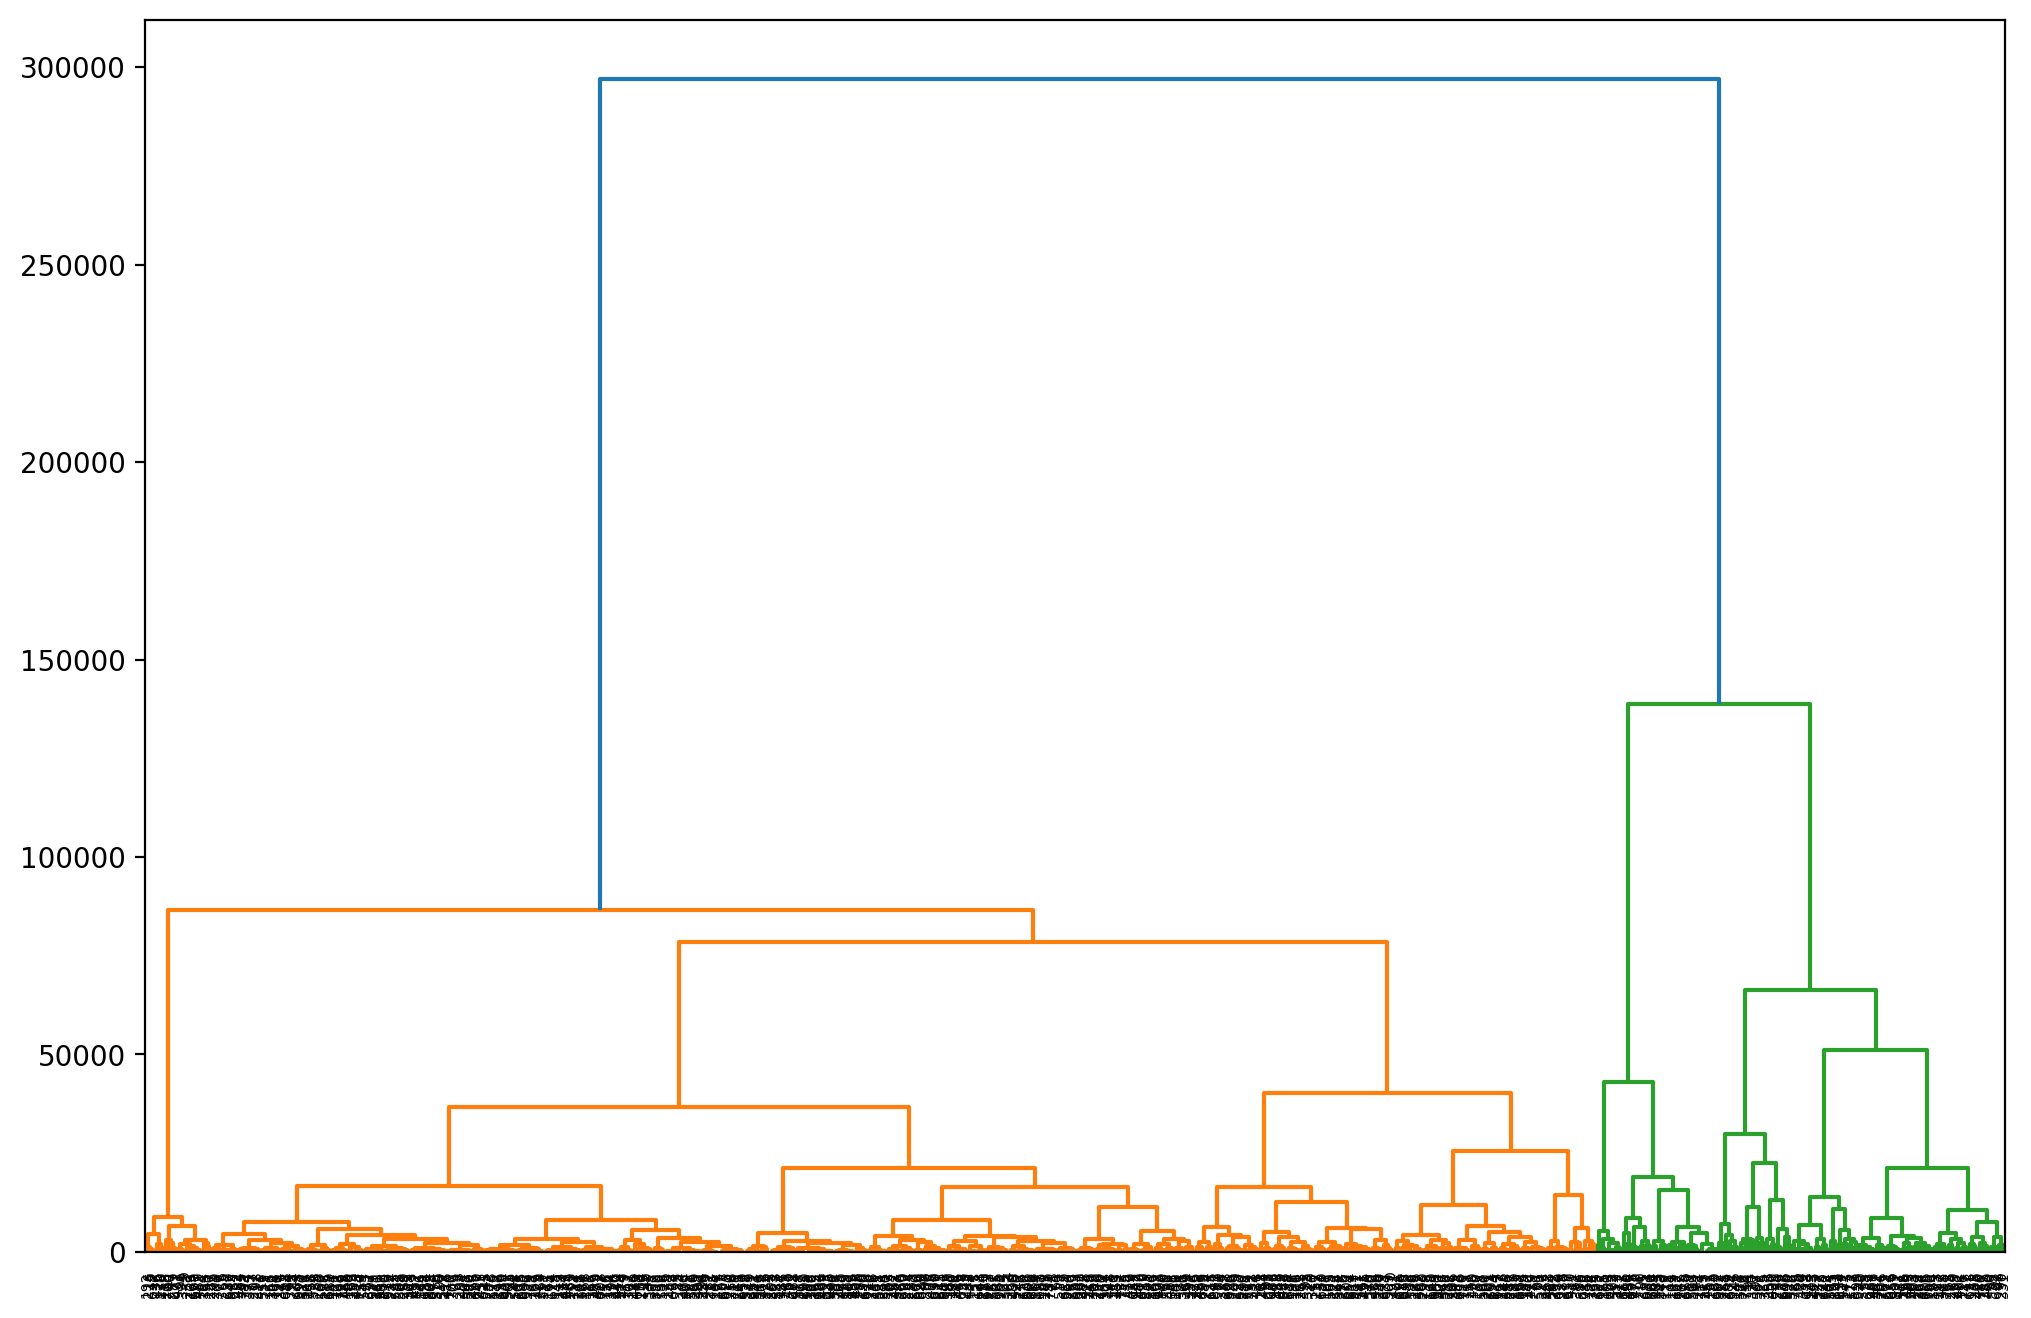

In [118]:
# Agregación de Ward
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(ward_res, ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

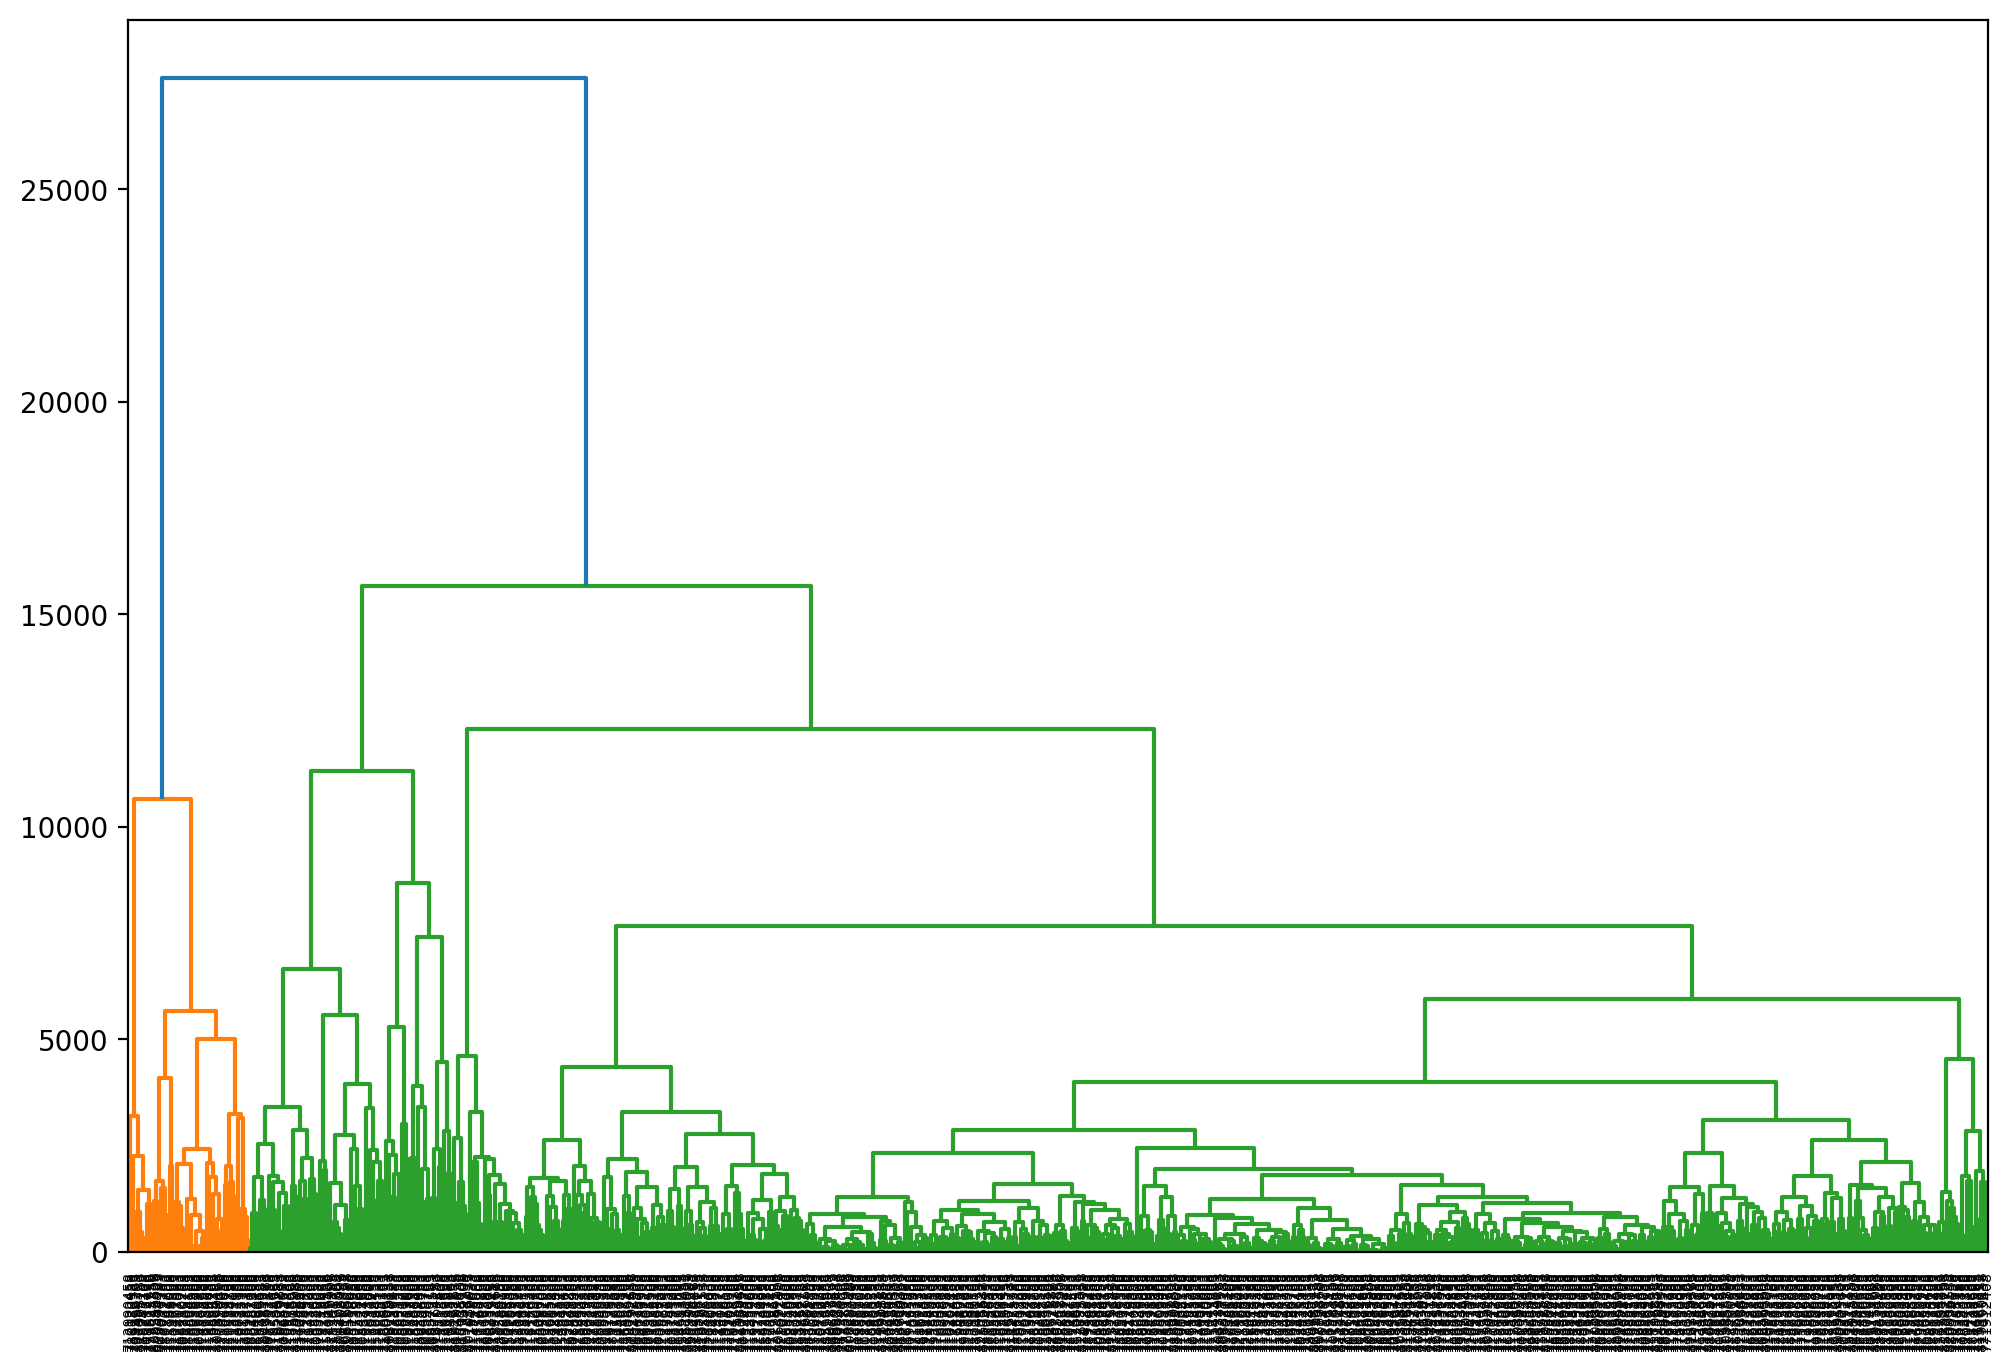

In [119]:
# Salto promedio
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(average_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

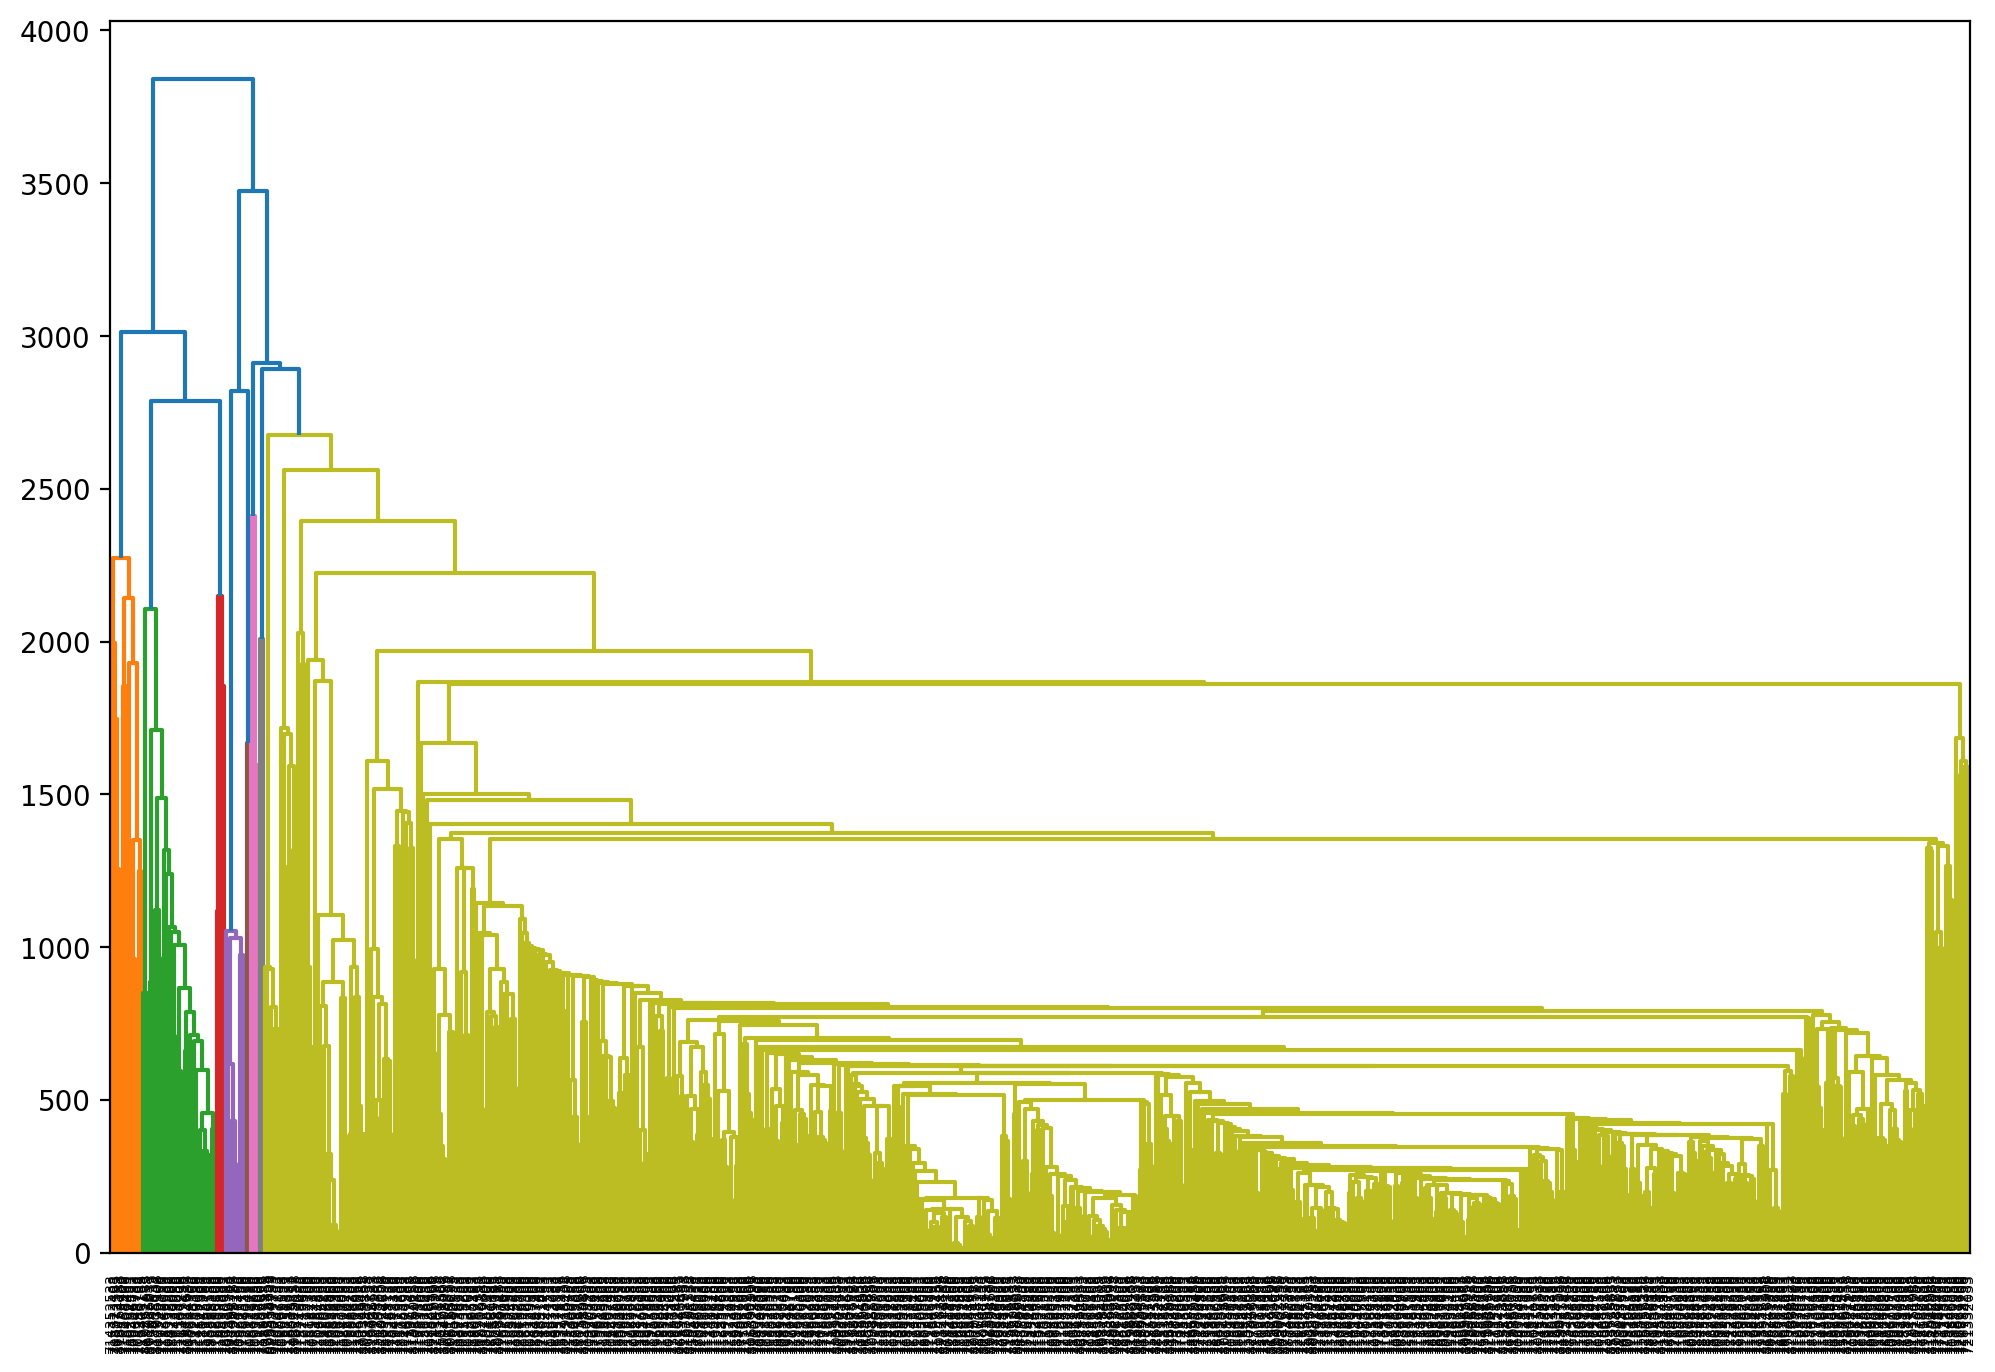

In [120]:
# Salto mínimo
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(single_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

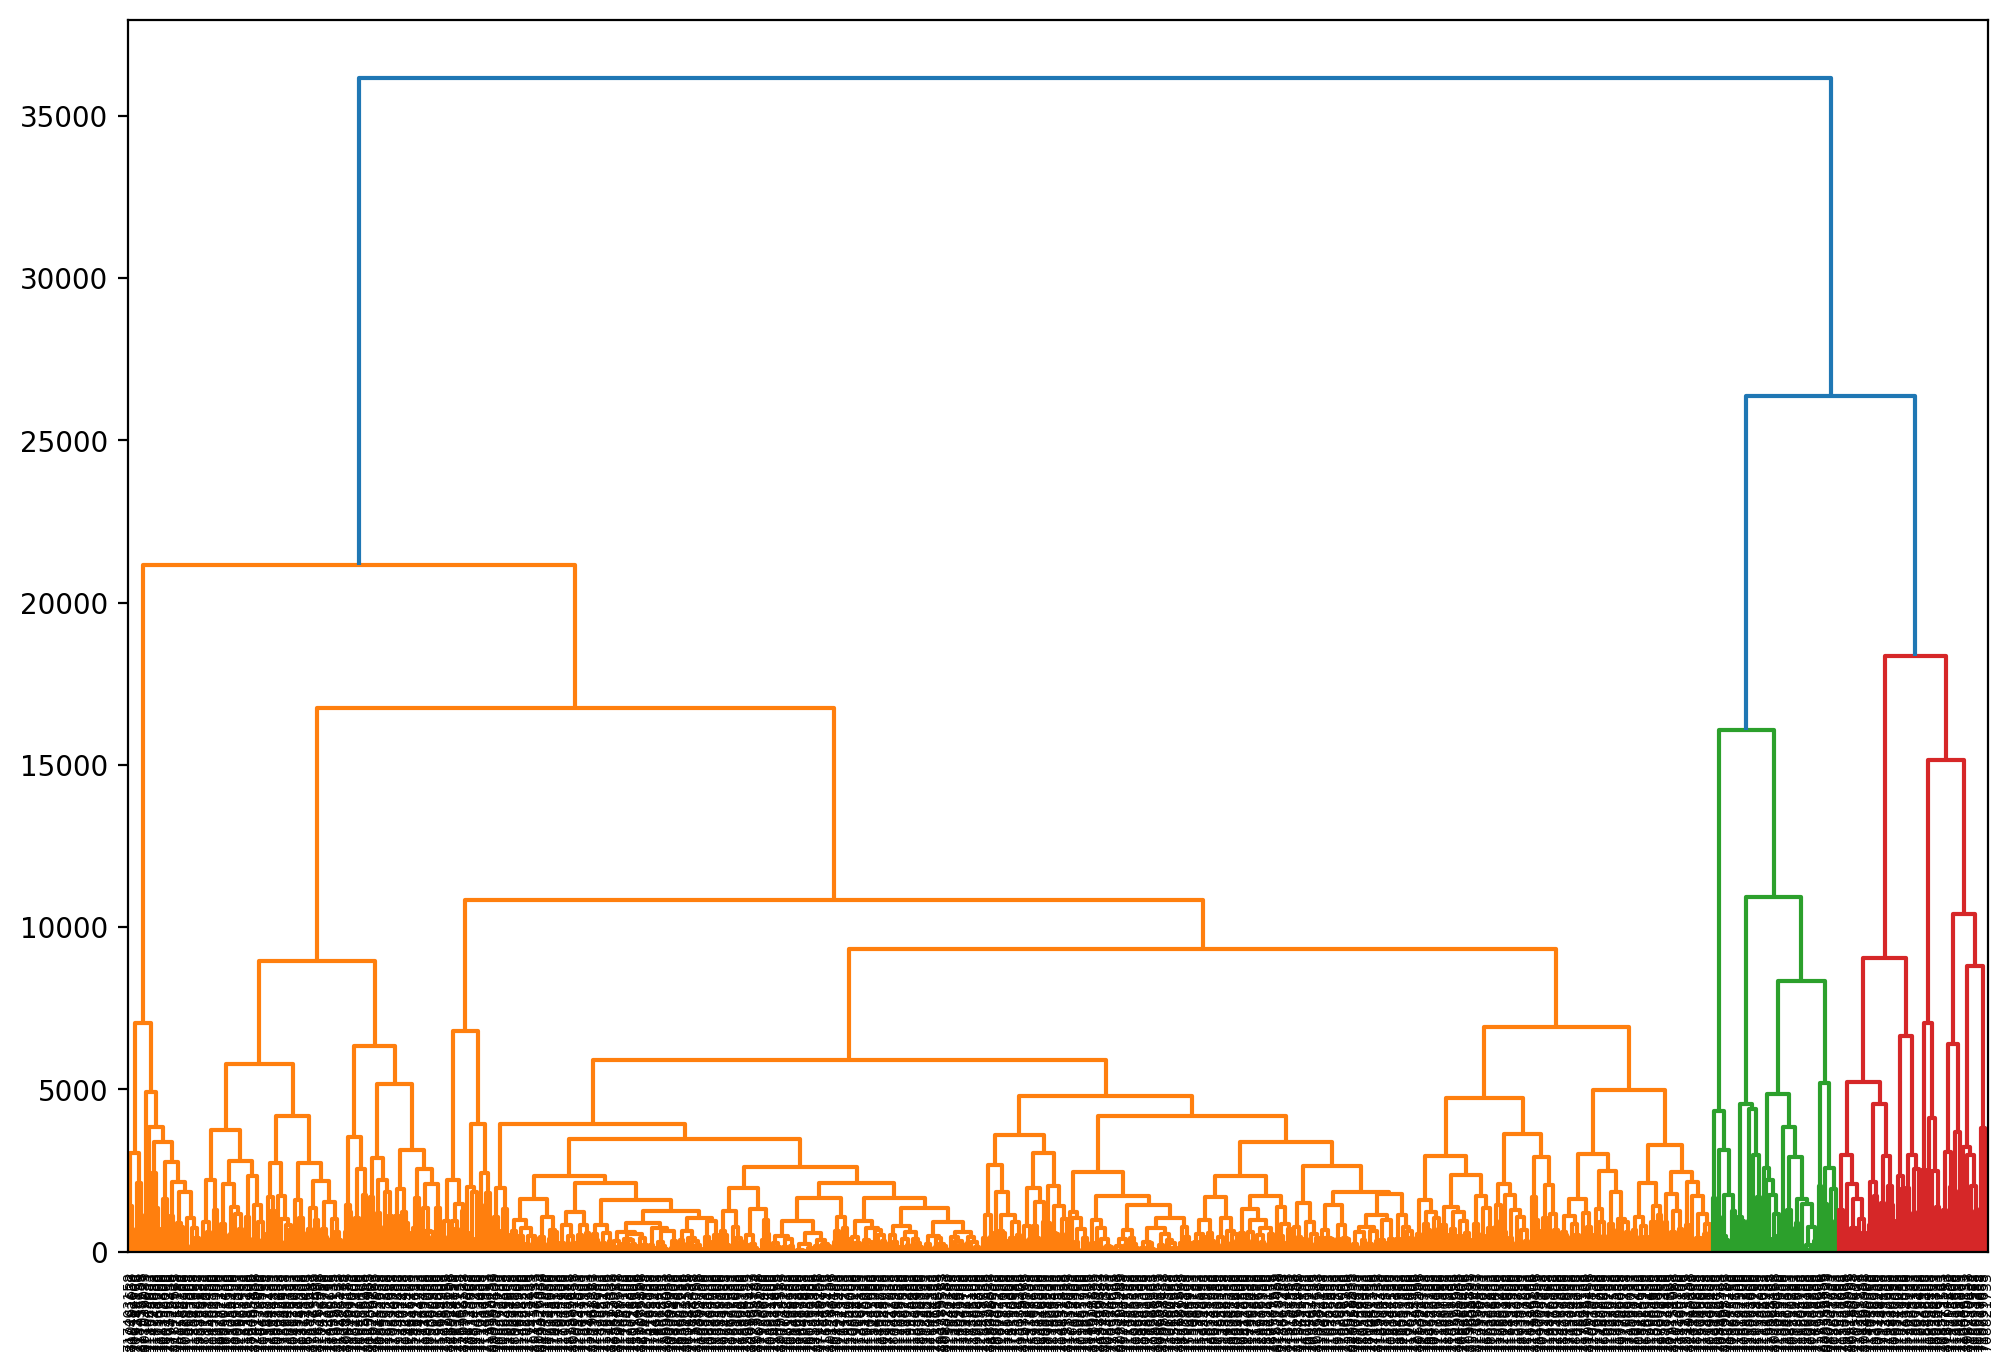

In [121]:
# Salto máximo
fig, ax = plt.subplots(1,1, figsize = (12,8), dpi = 200)
dendrogram(complete_res,labels = df_numerico.index.tolist(), ax = ax) #Aquí se escoge la agregación, distancia entre grupos.
plt.show()

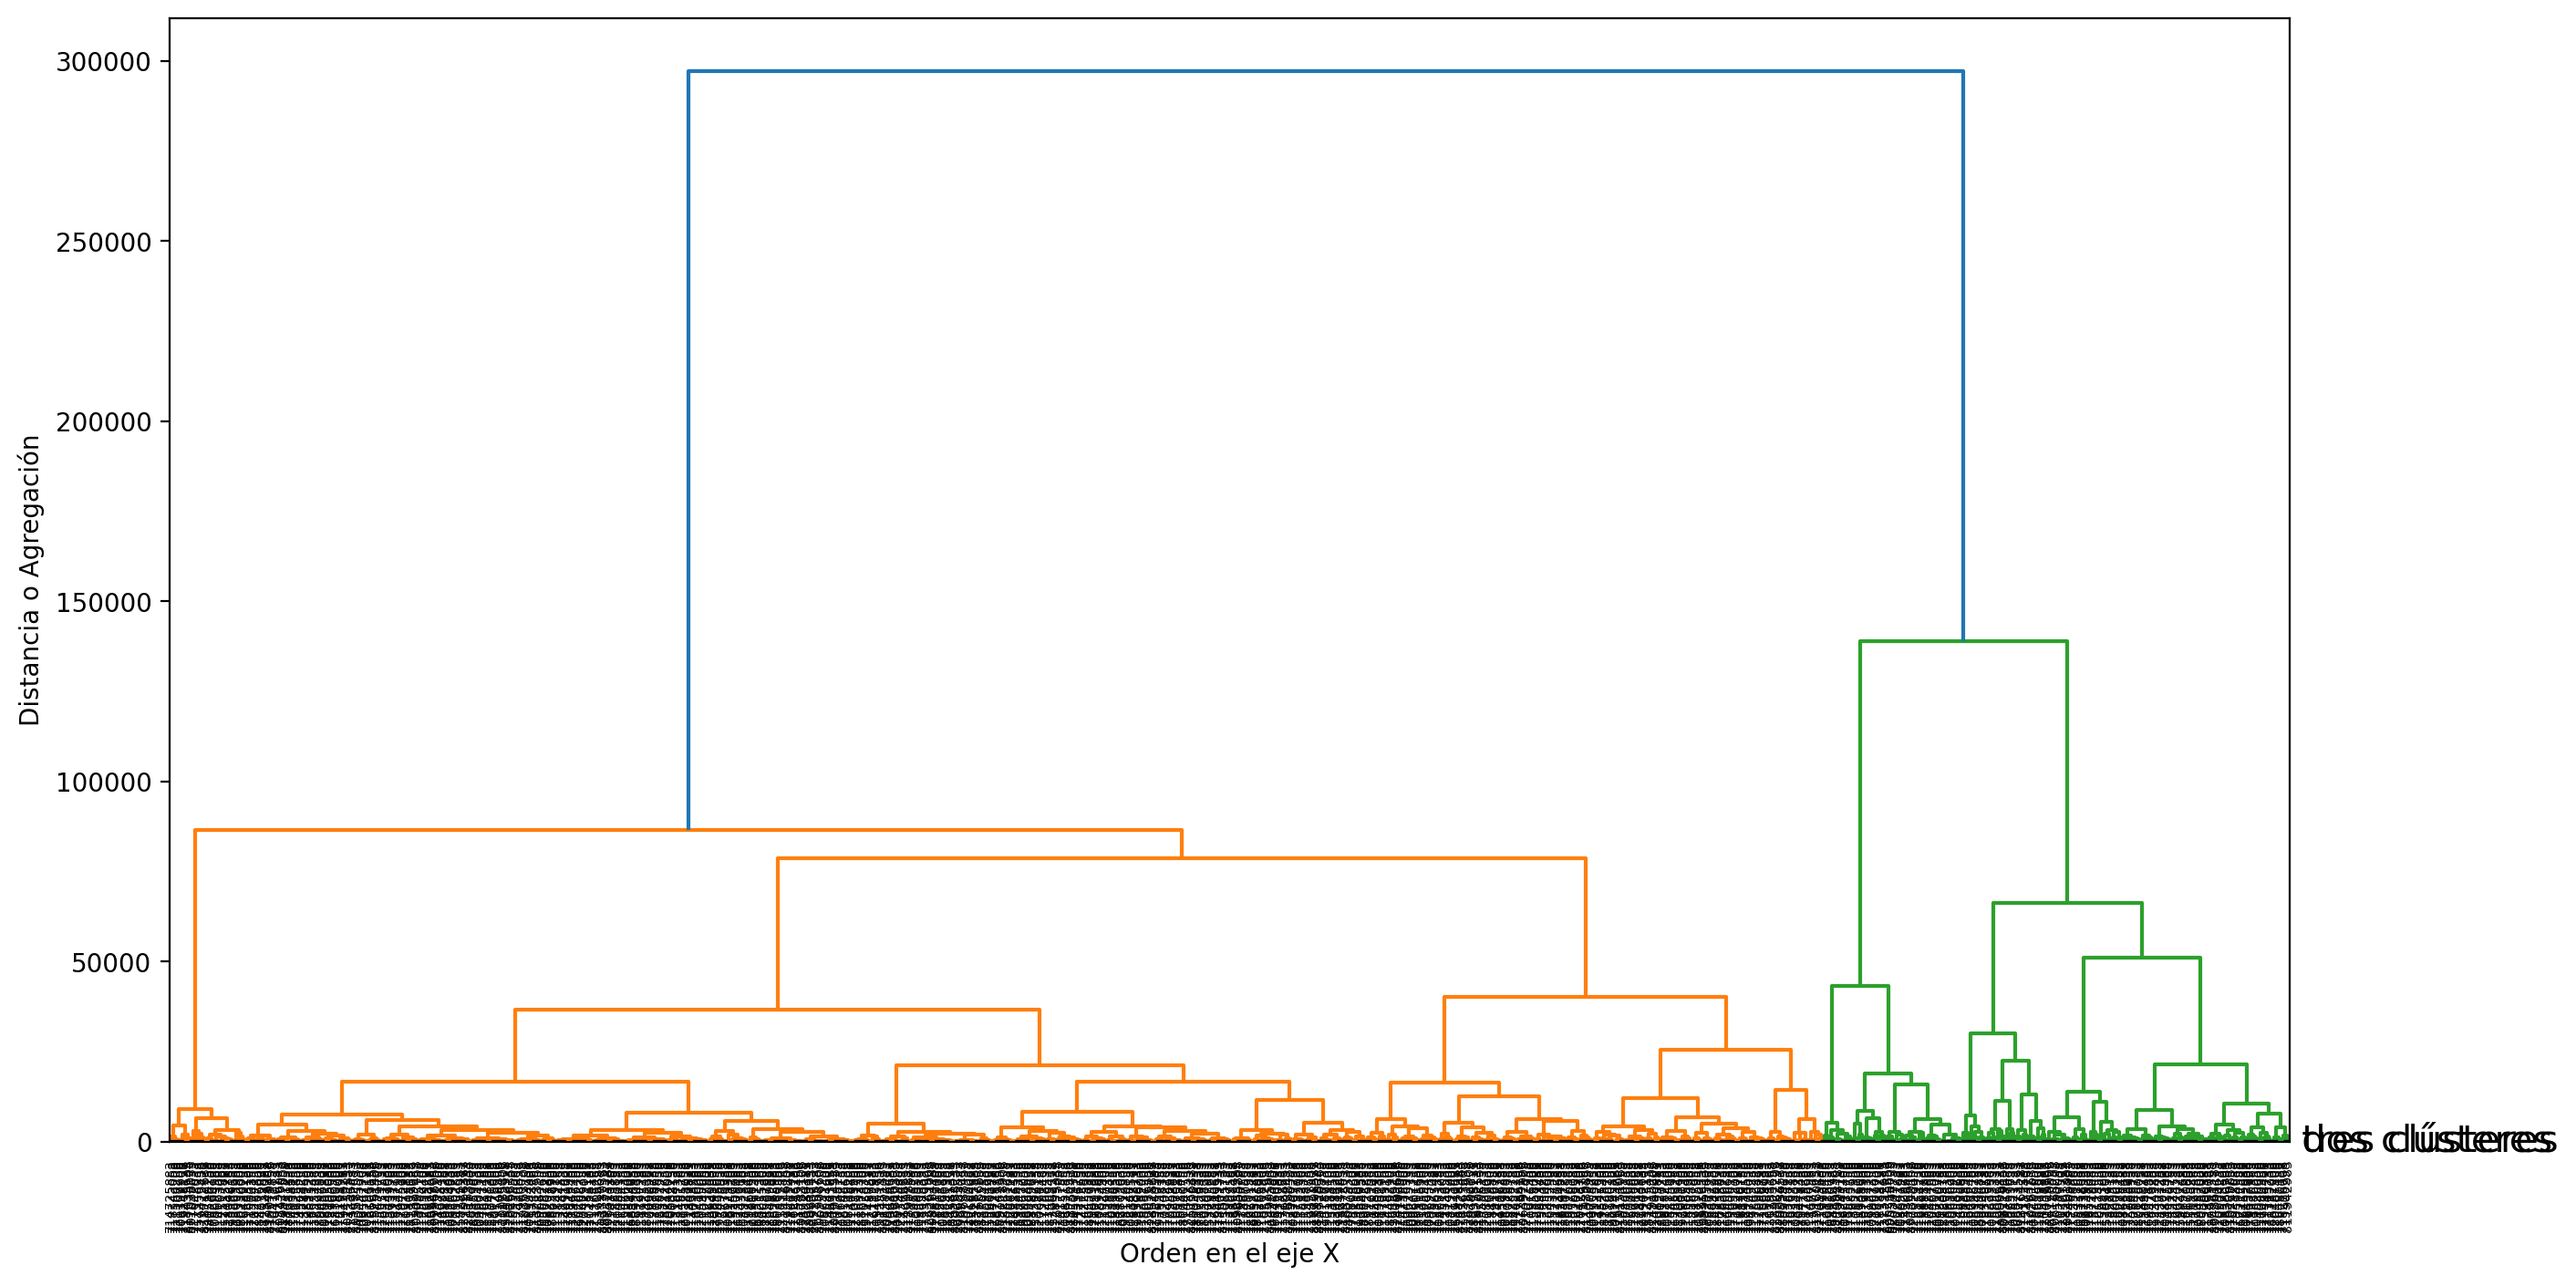

In [122]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(ward_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación de Ward
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

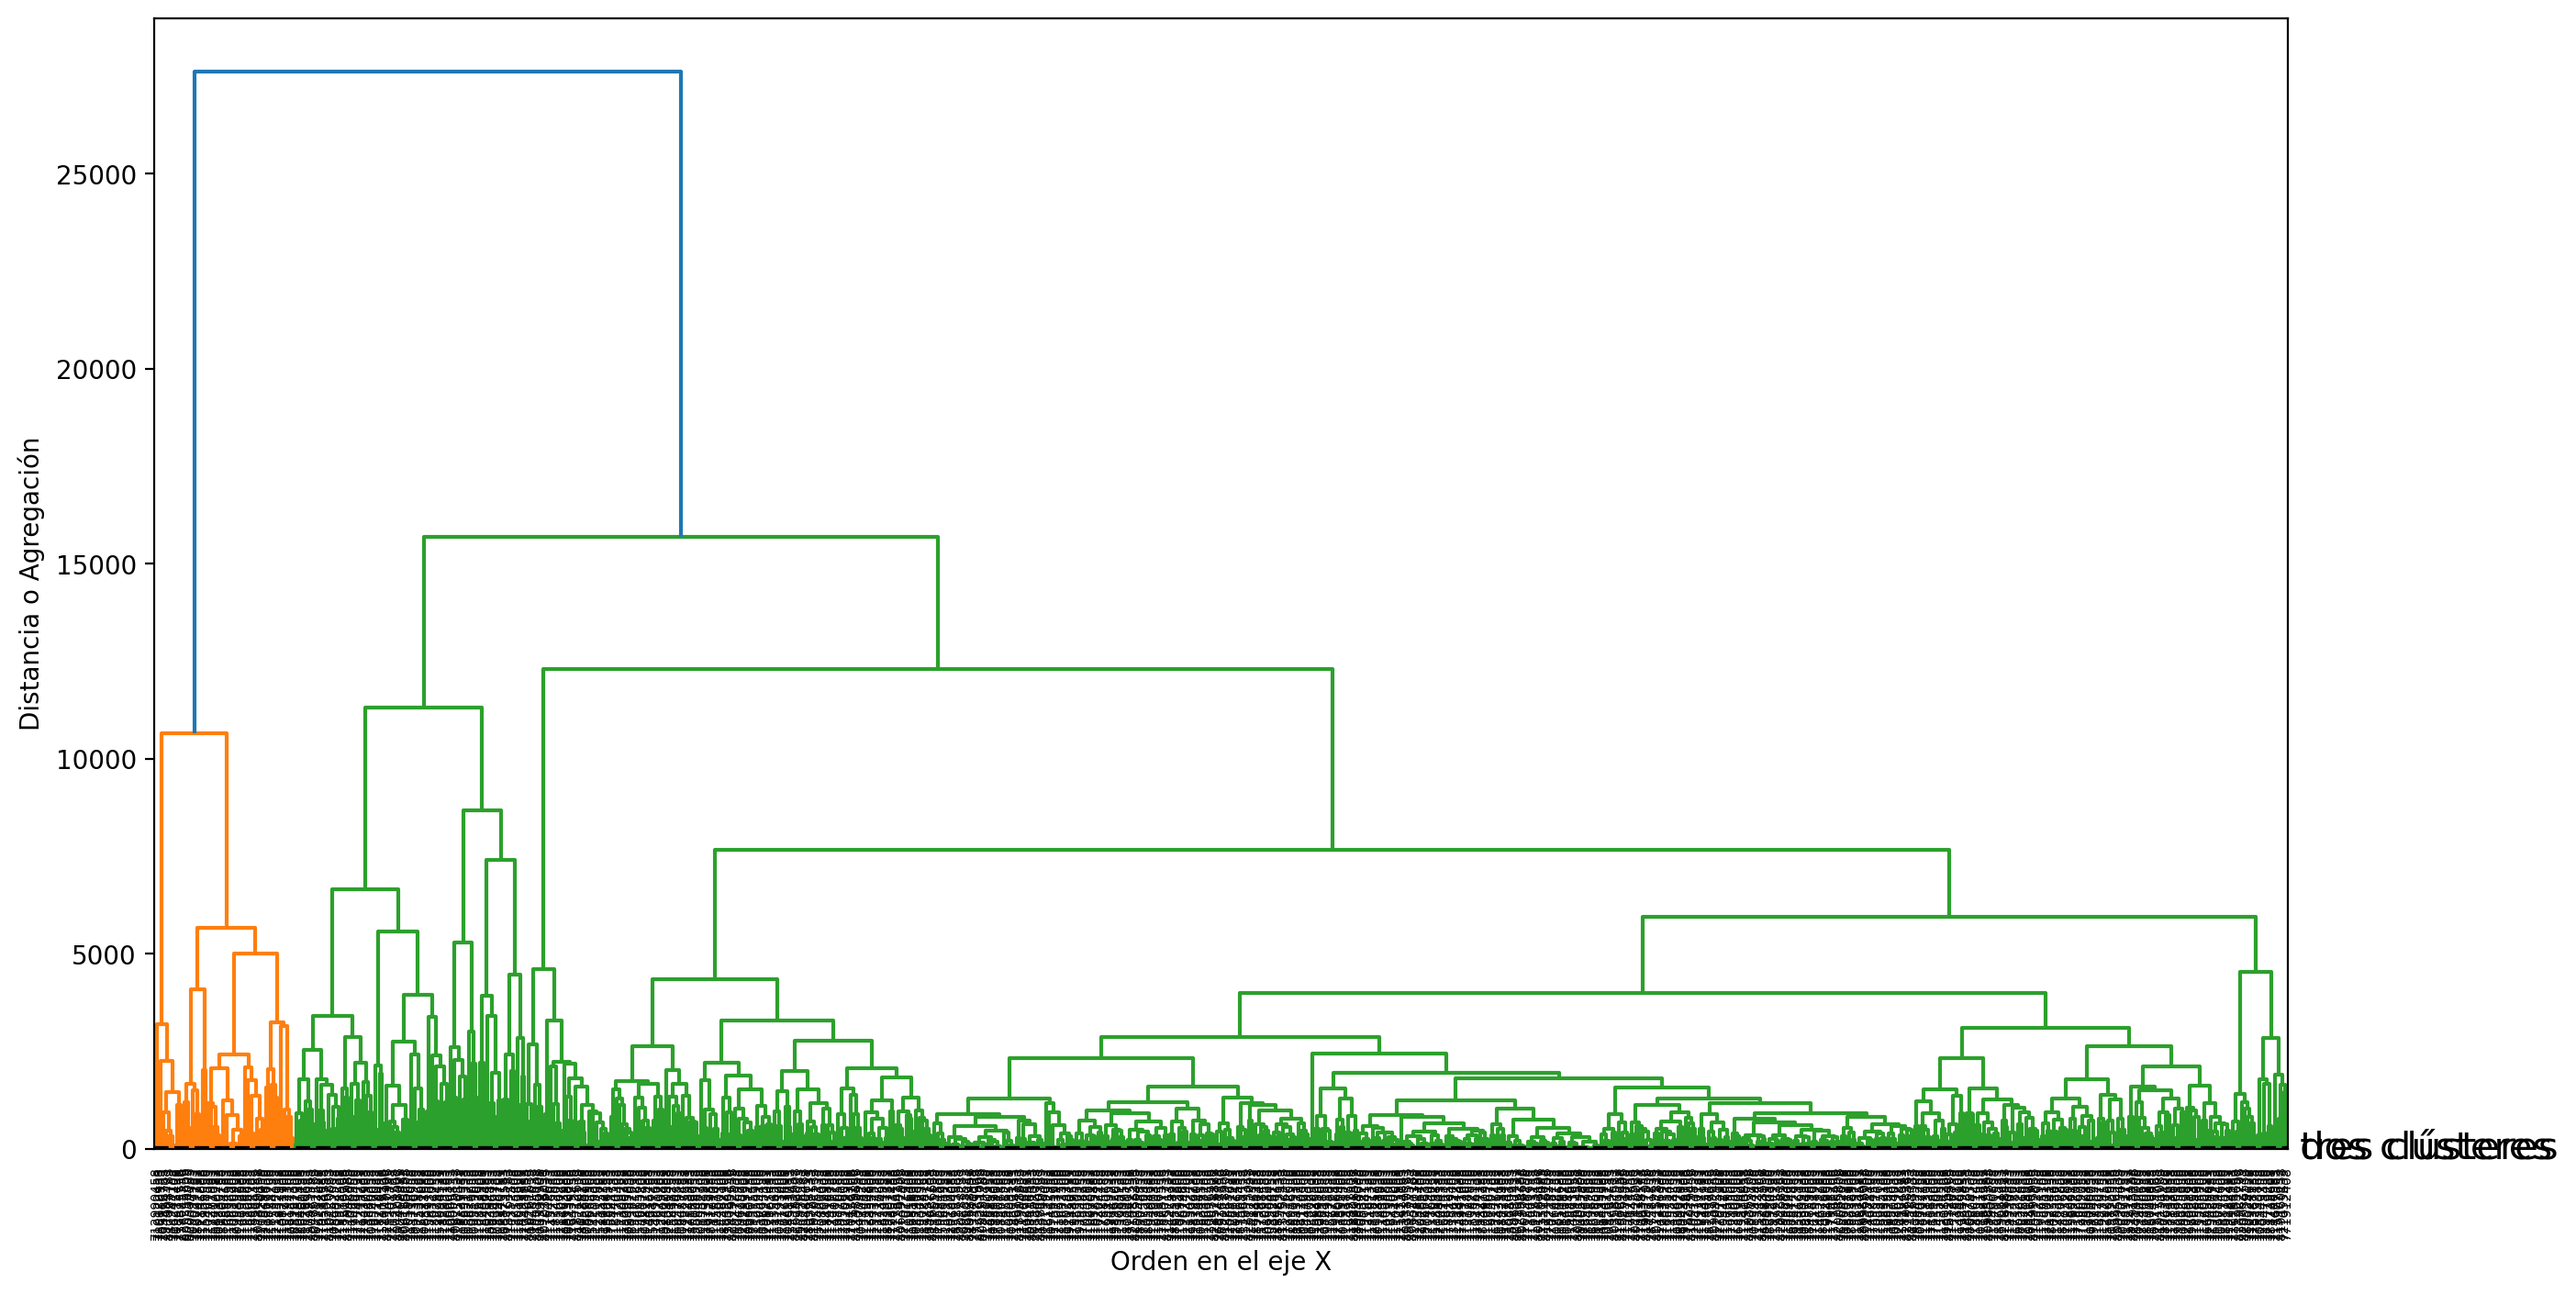

In [123]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(average_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación de average
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

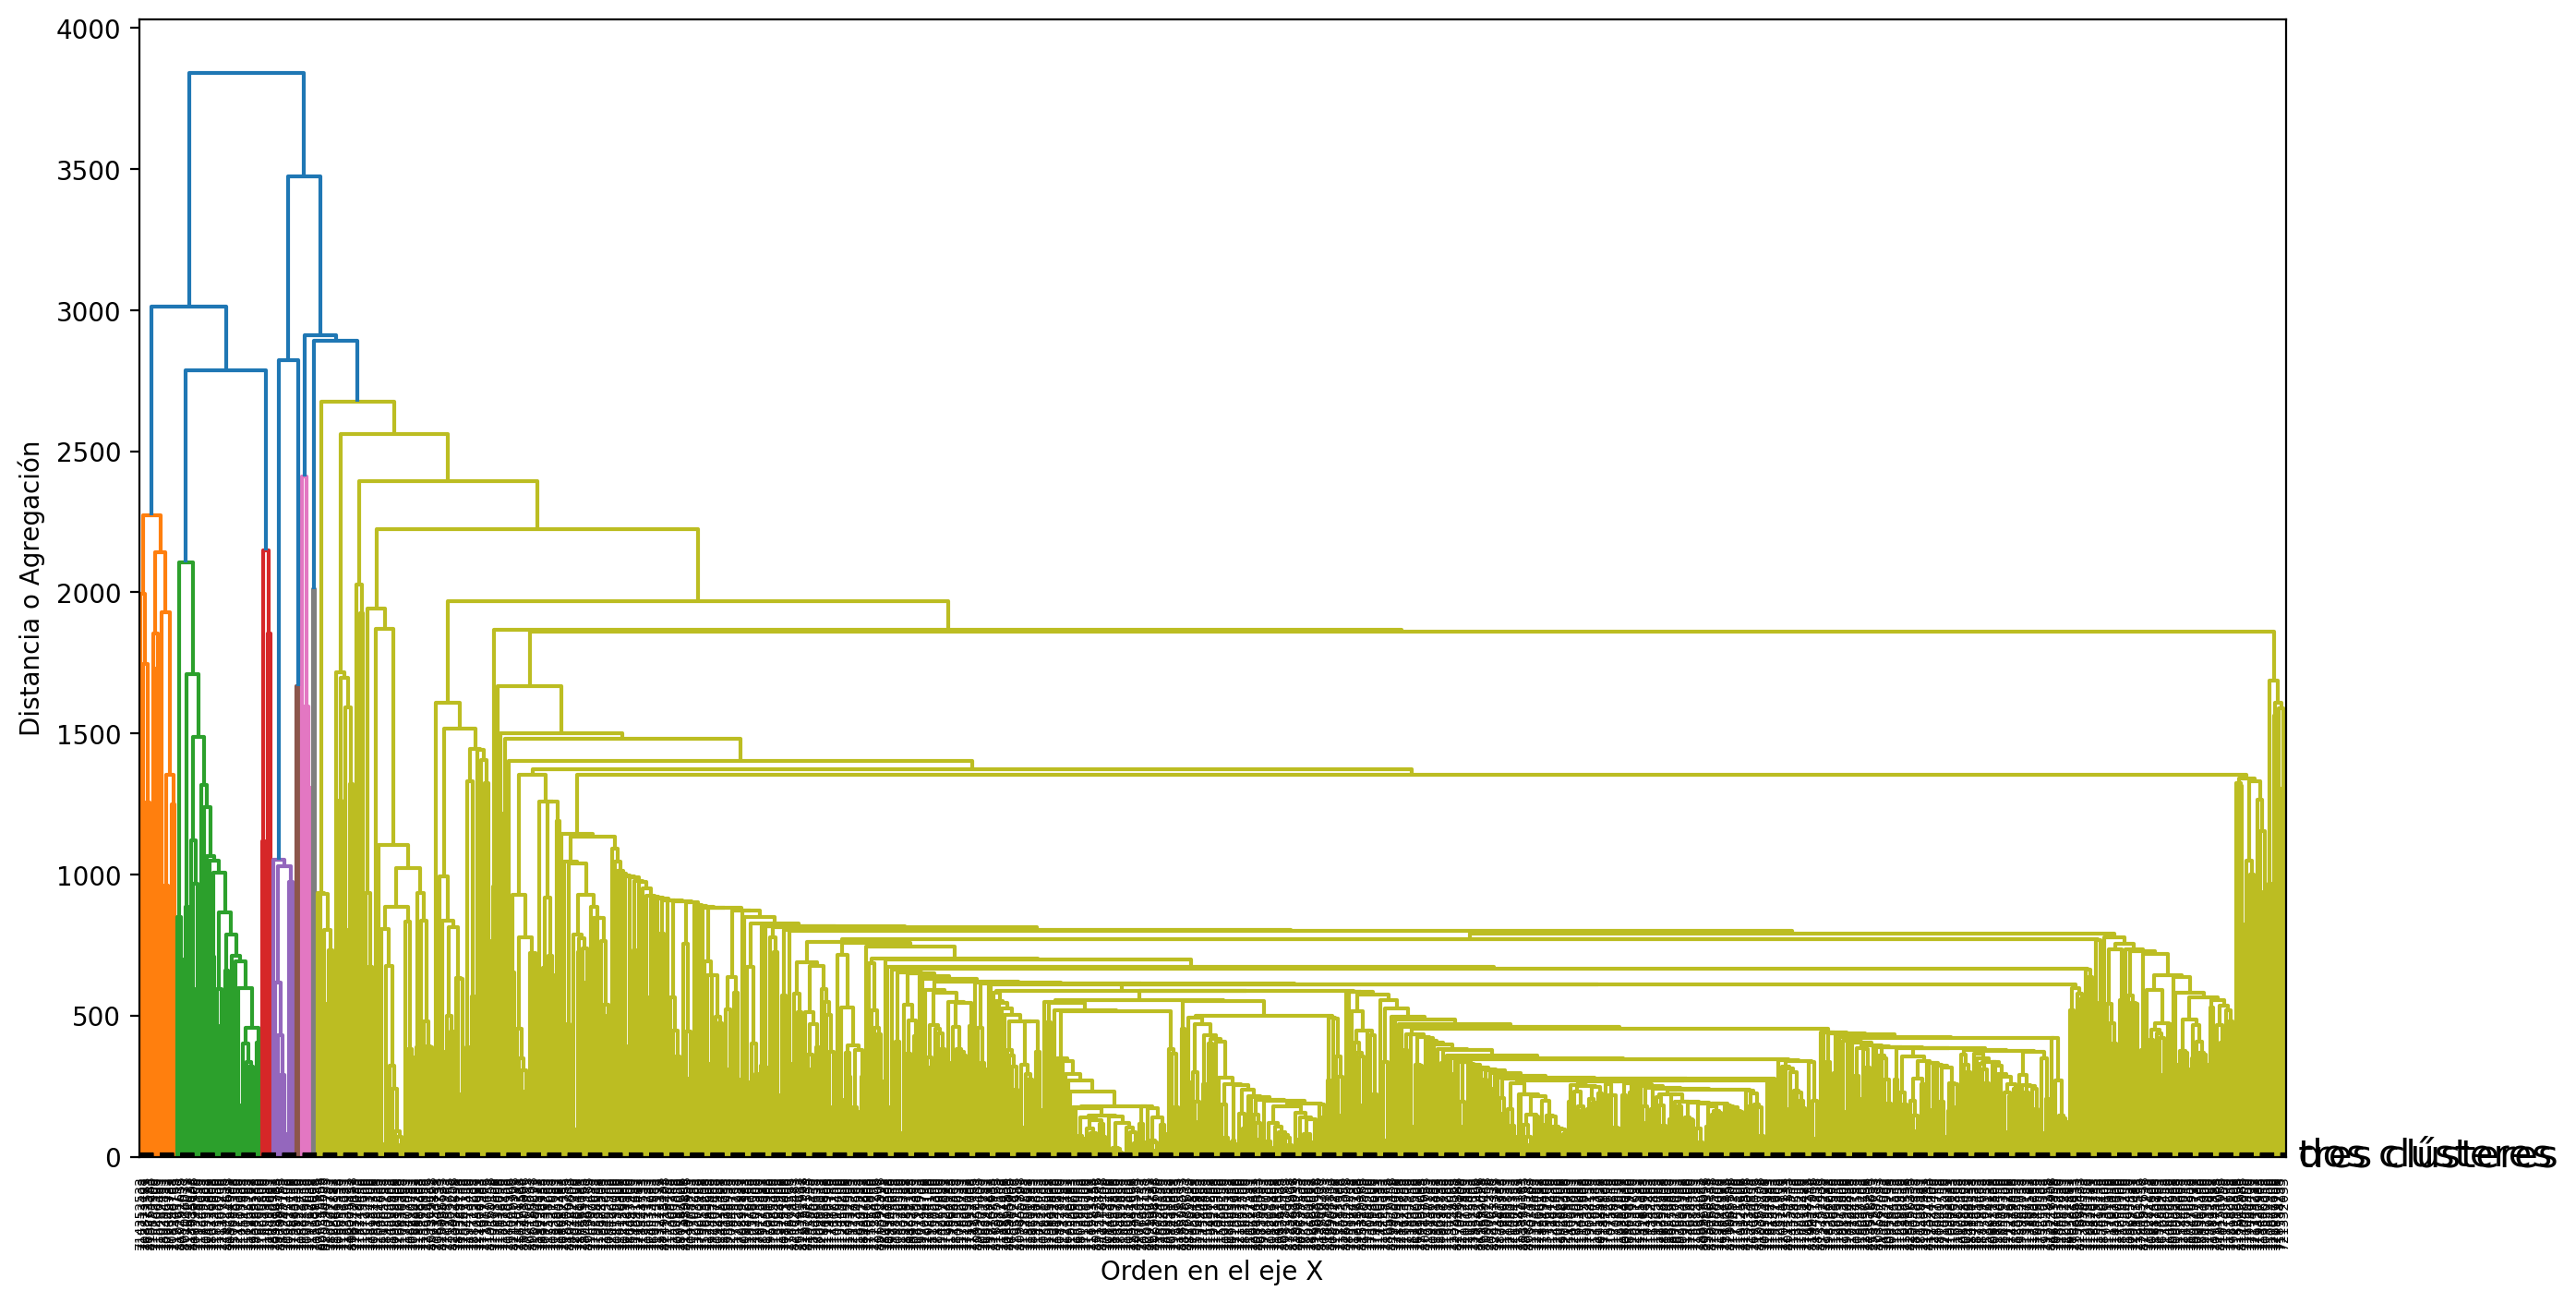

In [124]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(single_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación single
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

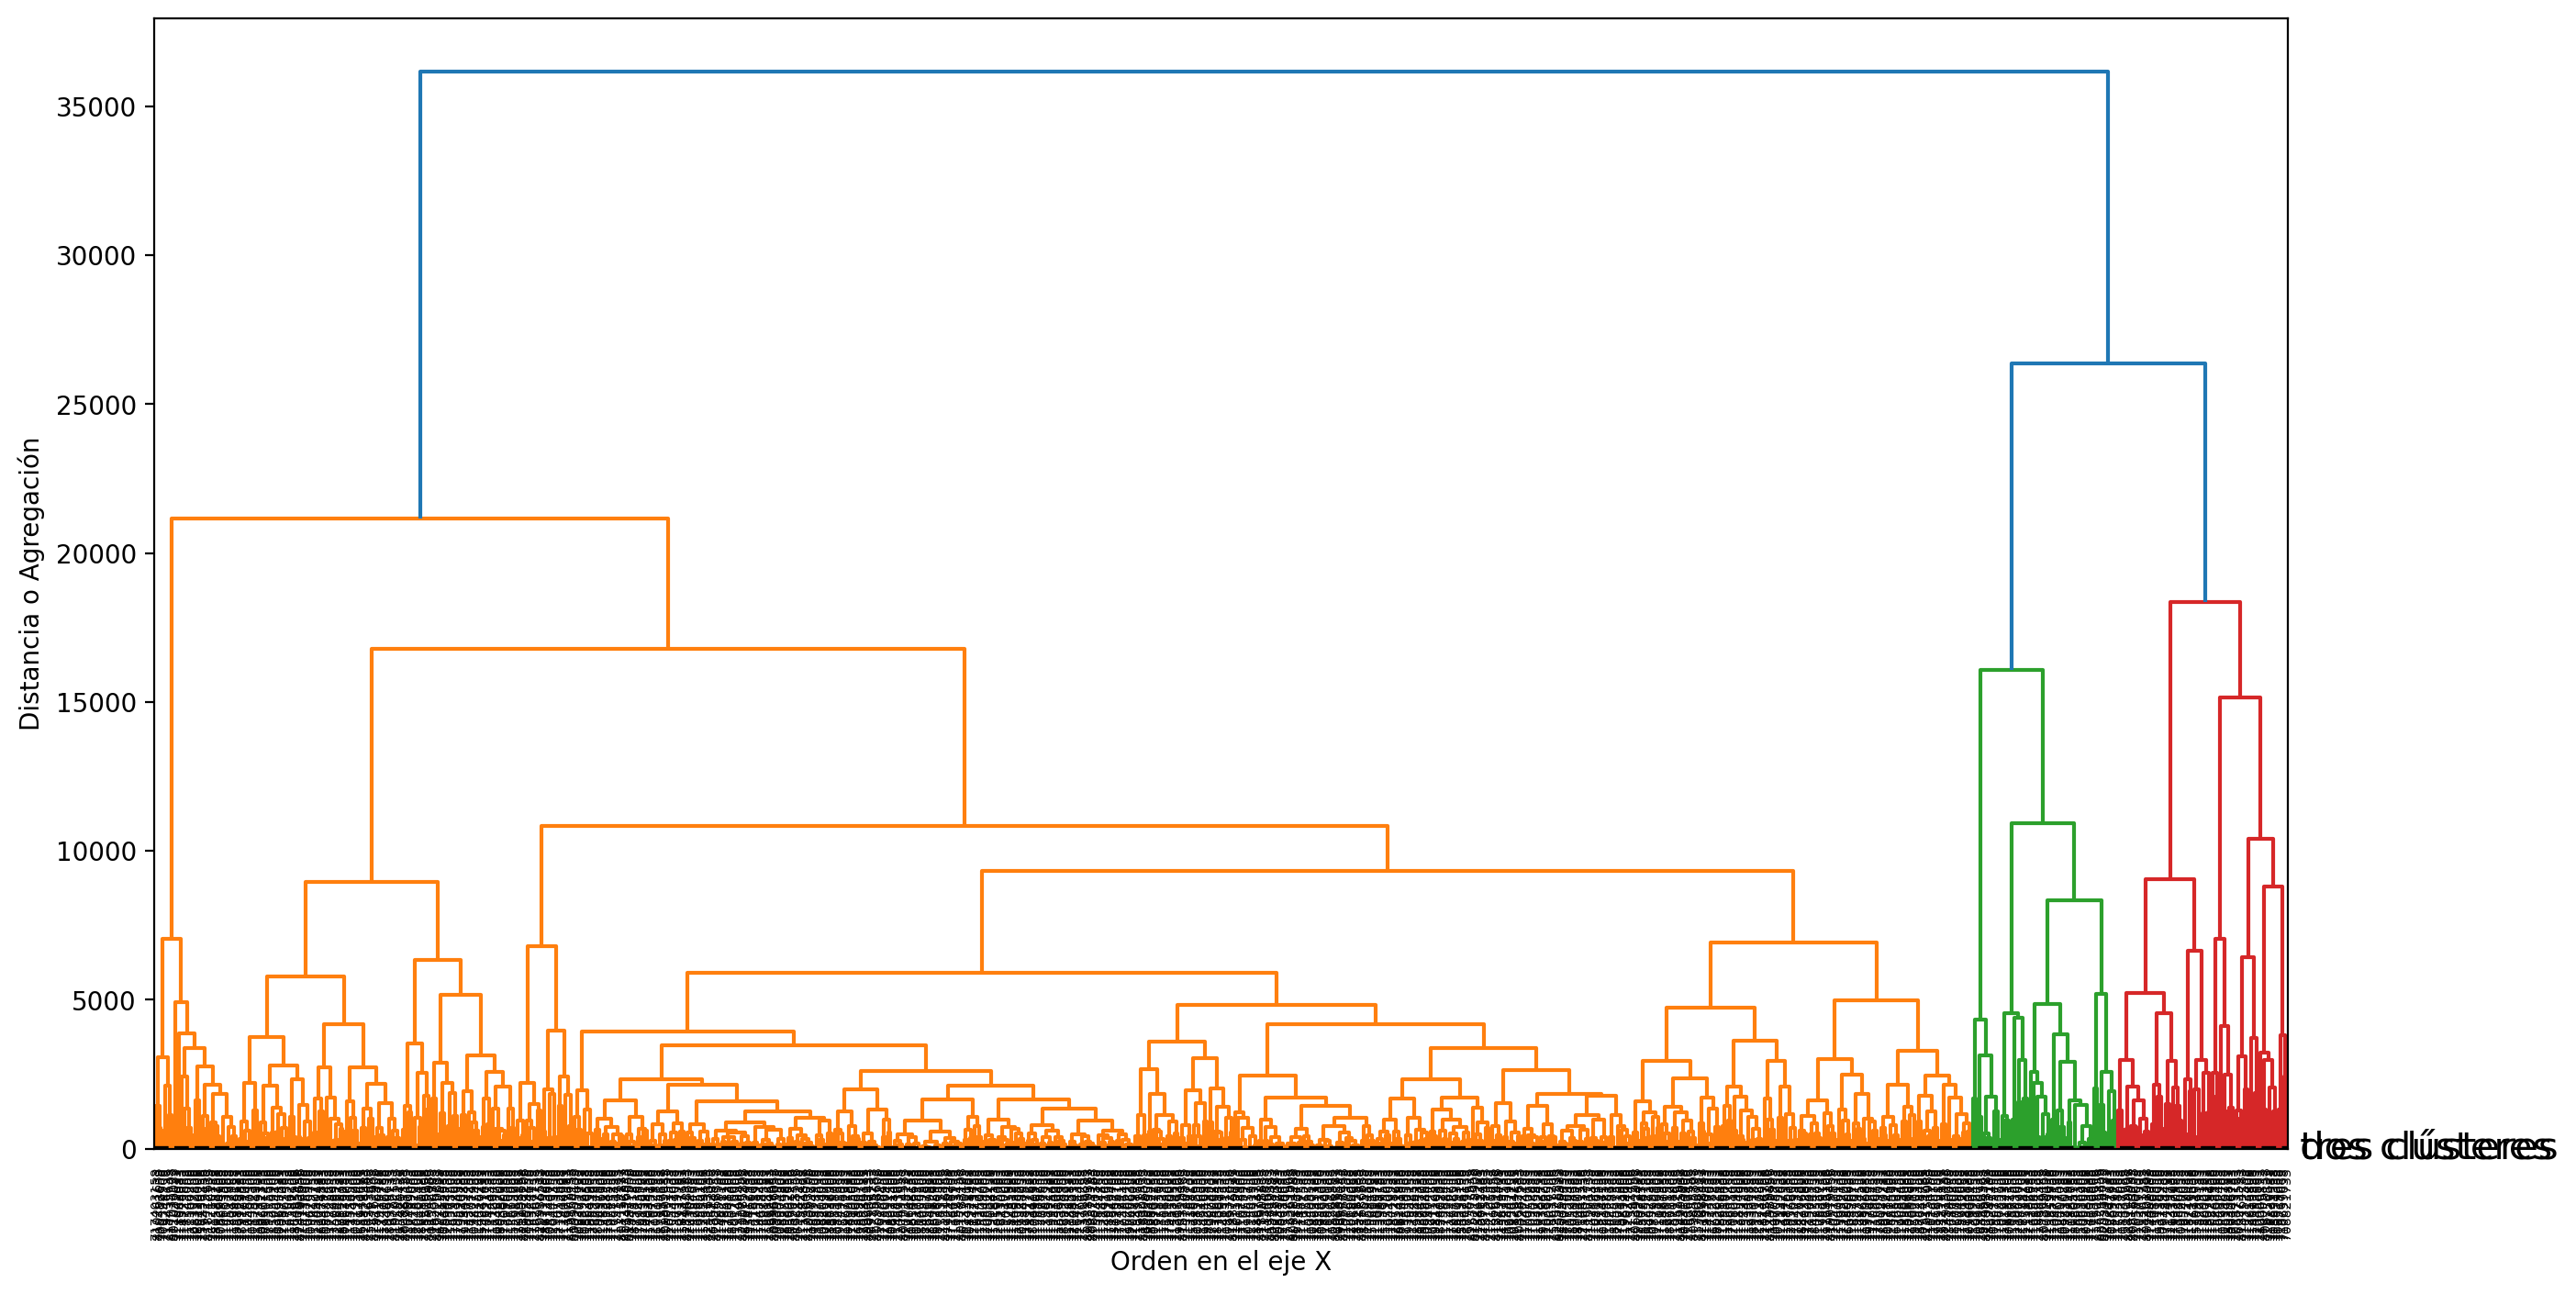

In [125]:
fig, ax = plt.subplots(1, 1, figsize = (15,8), dpi = 200)
dendrogram(complete_res, labels = df_numerico.index.tolist())

# Agrega cortes con 2 y 3 clústeres con agregación complete
limites = ax.get_xbound()
ax.plot(limites, [7.25, 7.25], '--', c='k')
ax.plot(limites, [4, 4], '--', c='k')
ax.text(limites[1], 7.25, ' dos clústeres', va = 'center', fontdict={'size': 15})
ax.text(limites[1], 4, ' tres clústeres',   va = 'center', fontdict={'size': 15})
ax.set_xlabel("Orden en el eje X")
ax.set_ylabel("Distancia o Agregación")
plt.show()

In [126]:
grupos = fcluster(linkage(df_numerico, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
grupos

array([0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0,
       2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2,
       0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 2, 2, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,

In [127]:
centros = np.array(pd.concat([ns.centroide(0, df_numerico, grupos), 
                              ns.centroide(1, df_numerico, grupos),
                              ns.centroide(2, df_numerico, grupos)]))
centros

array([[4.64446203e+01, 2.22943038e+00, 3.58386076e+01, 3.84493671e+00,
        2.32120253e+00, 2.42088608e+00, 4.22284731e+03, 1.14586392e+03,
        3.97528323e+03, 6.29208861e+01],
       [4.59622642e+01, 2.86792453e+00, 3.54528302e+01, 3.43396226e+00,
        2.35849057e+00, 2.56603774e+00, 3.32653019e+04, 1.35262264e+03,
        6.06701887e+03, 7.19056604e+01],
       [4.61840000e+01, 2.31200000e+00, 3.60880000e+01, 3.68800000e+00,
        2.34400000e+00, 2.43200000e+00, 1.71836480e+04, 1.13212000e+03,
        5.48491200e+03, 6.80560000e+01]])

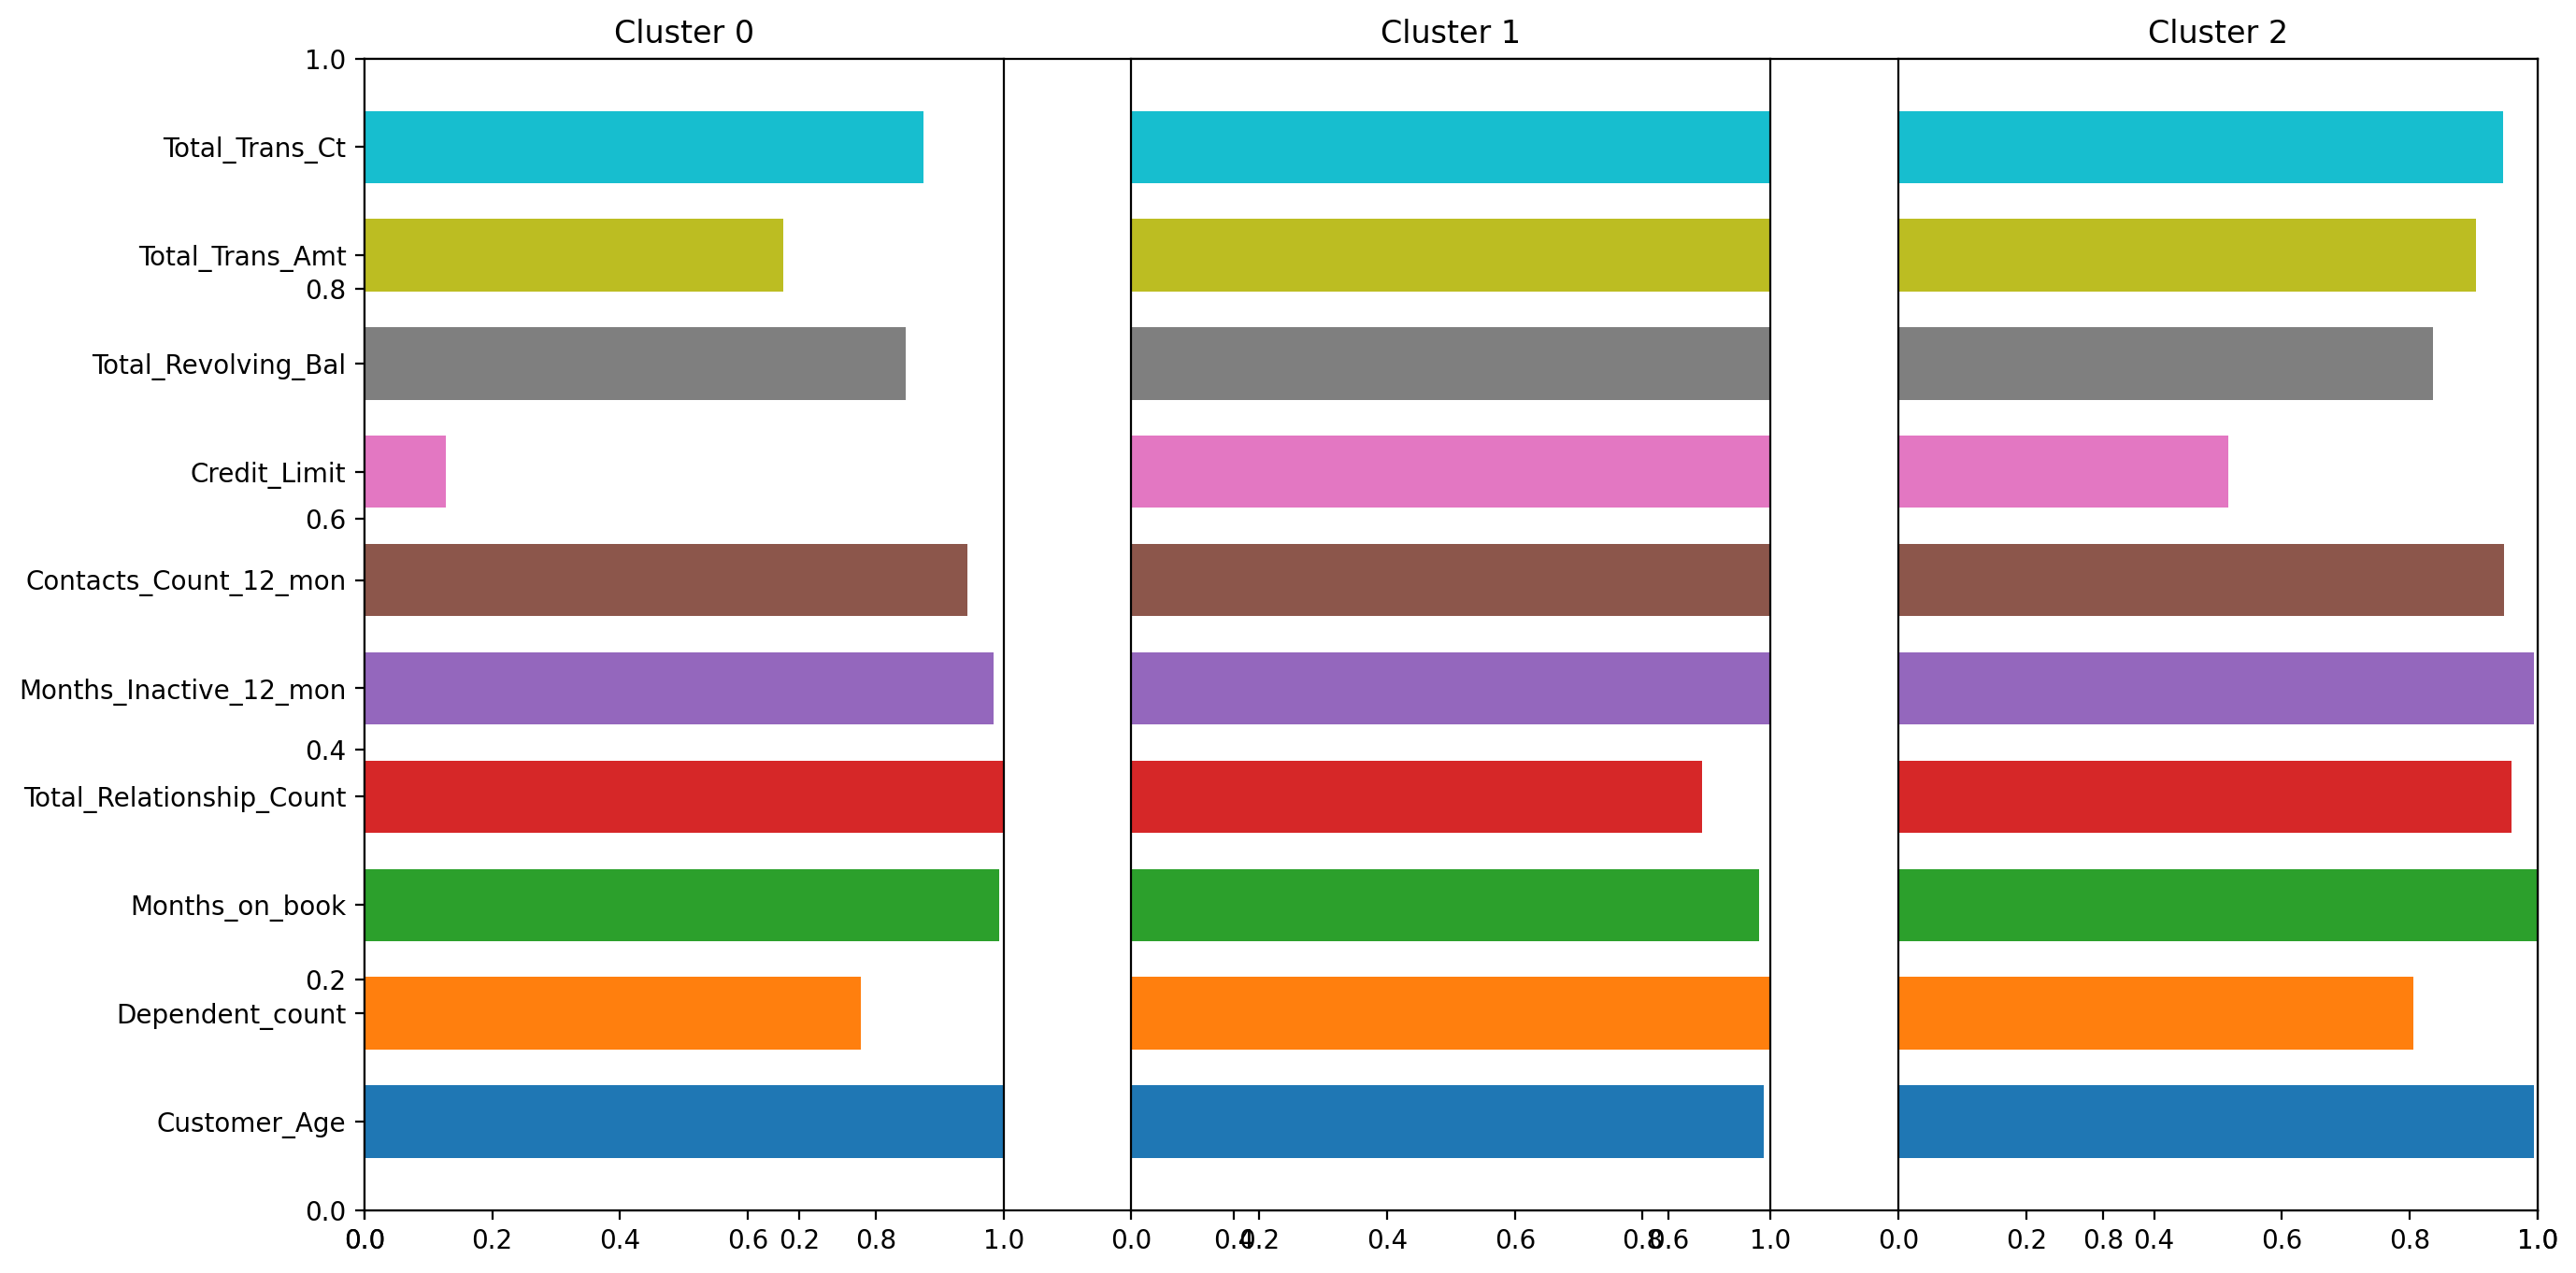

In [128]:
# Grafico de tipo barras
ns.bar_plot(centros, df_numerico.columns, scale=True)
plt.show()

[[4.64446203e+01 2.22943038e+00 3.58386076e+01 3.84493671e+00
  2.32120253e+00 2.42088608e+00 4.22284731e+03 1.14586392e+03
  3.97528323e+03 6.29208861e+01]
 [4.59622642e+01 2.86792453e+00 3.54528302e+01 3.43396226e+00
  2.35849057e+00 2.56603774e+00 3.32653019e+04 1.35262264e+03
  6.06701887e+03 7.19056604e+01]
 [4.61840000e+01 2.31200000e+00 3.60880000e+01 3.68800000e+00
  2.34400000e+00 2.43200000e+00 1.71836480e+04 1.13212000e+03
  5.48491200e+03 6.80560000e+01]]


/home/dnunezf/Documents/AI_LABS/Lab_12-03-2026/No_Supervisados.py:59: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize = figsize,dpi = dpi)


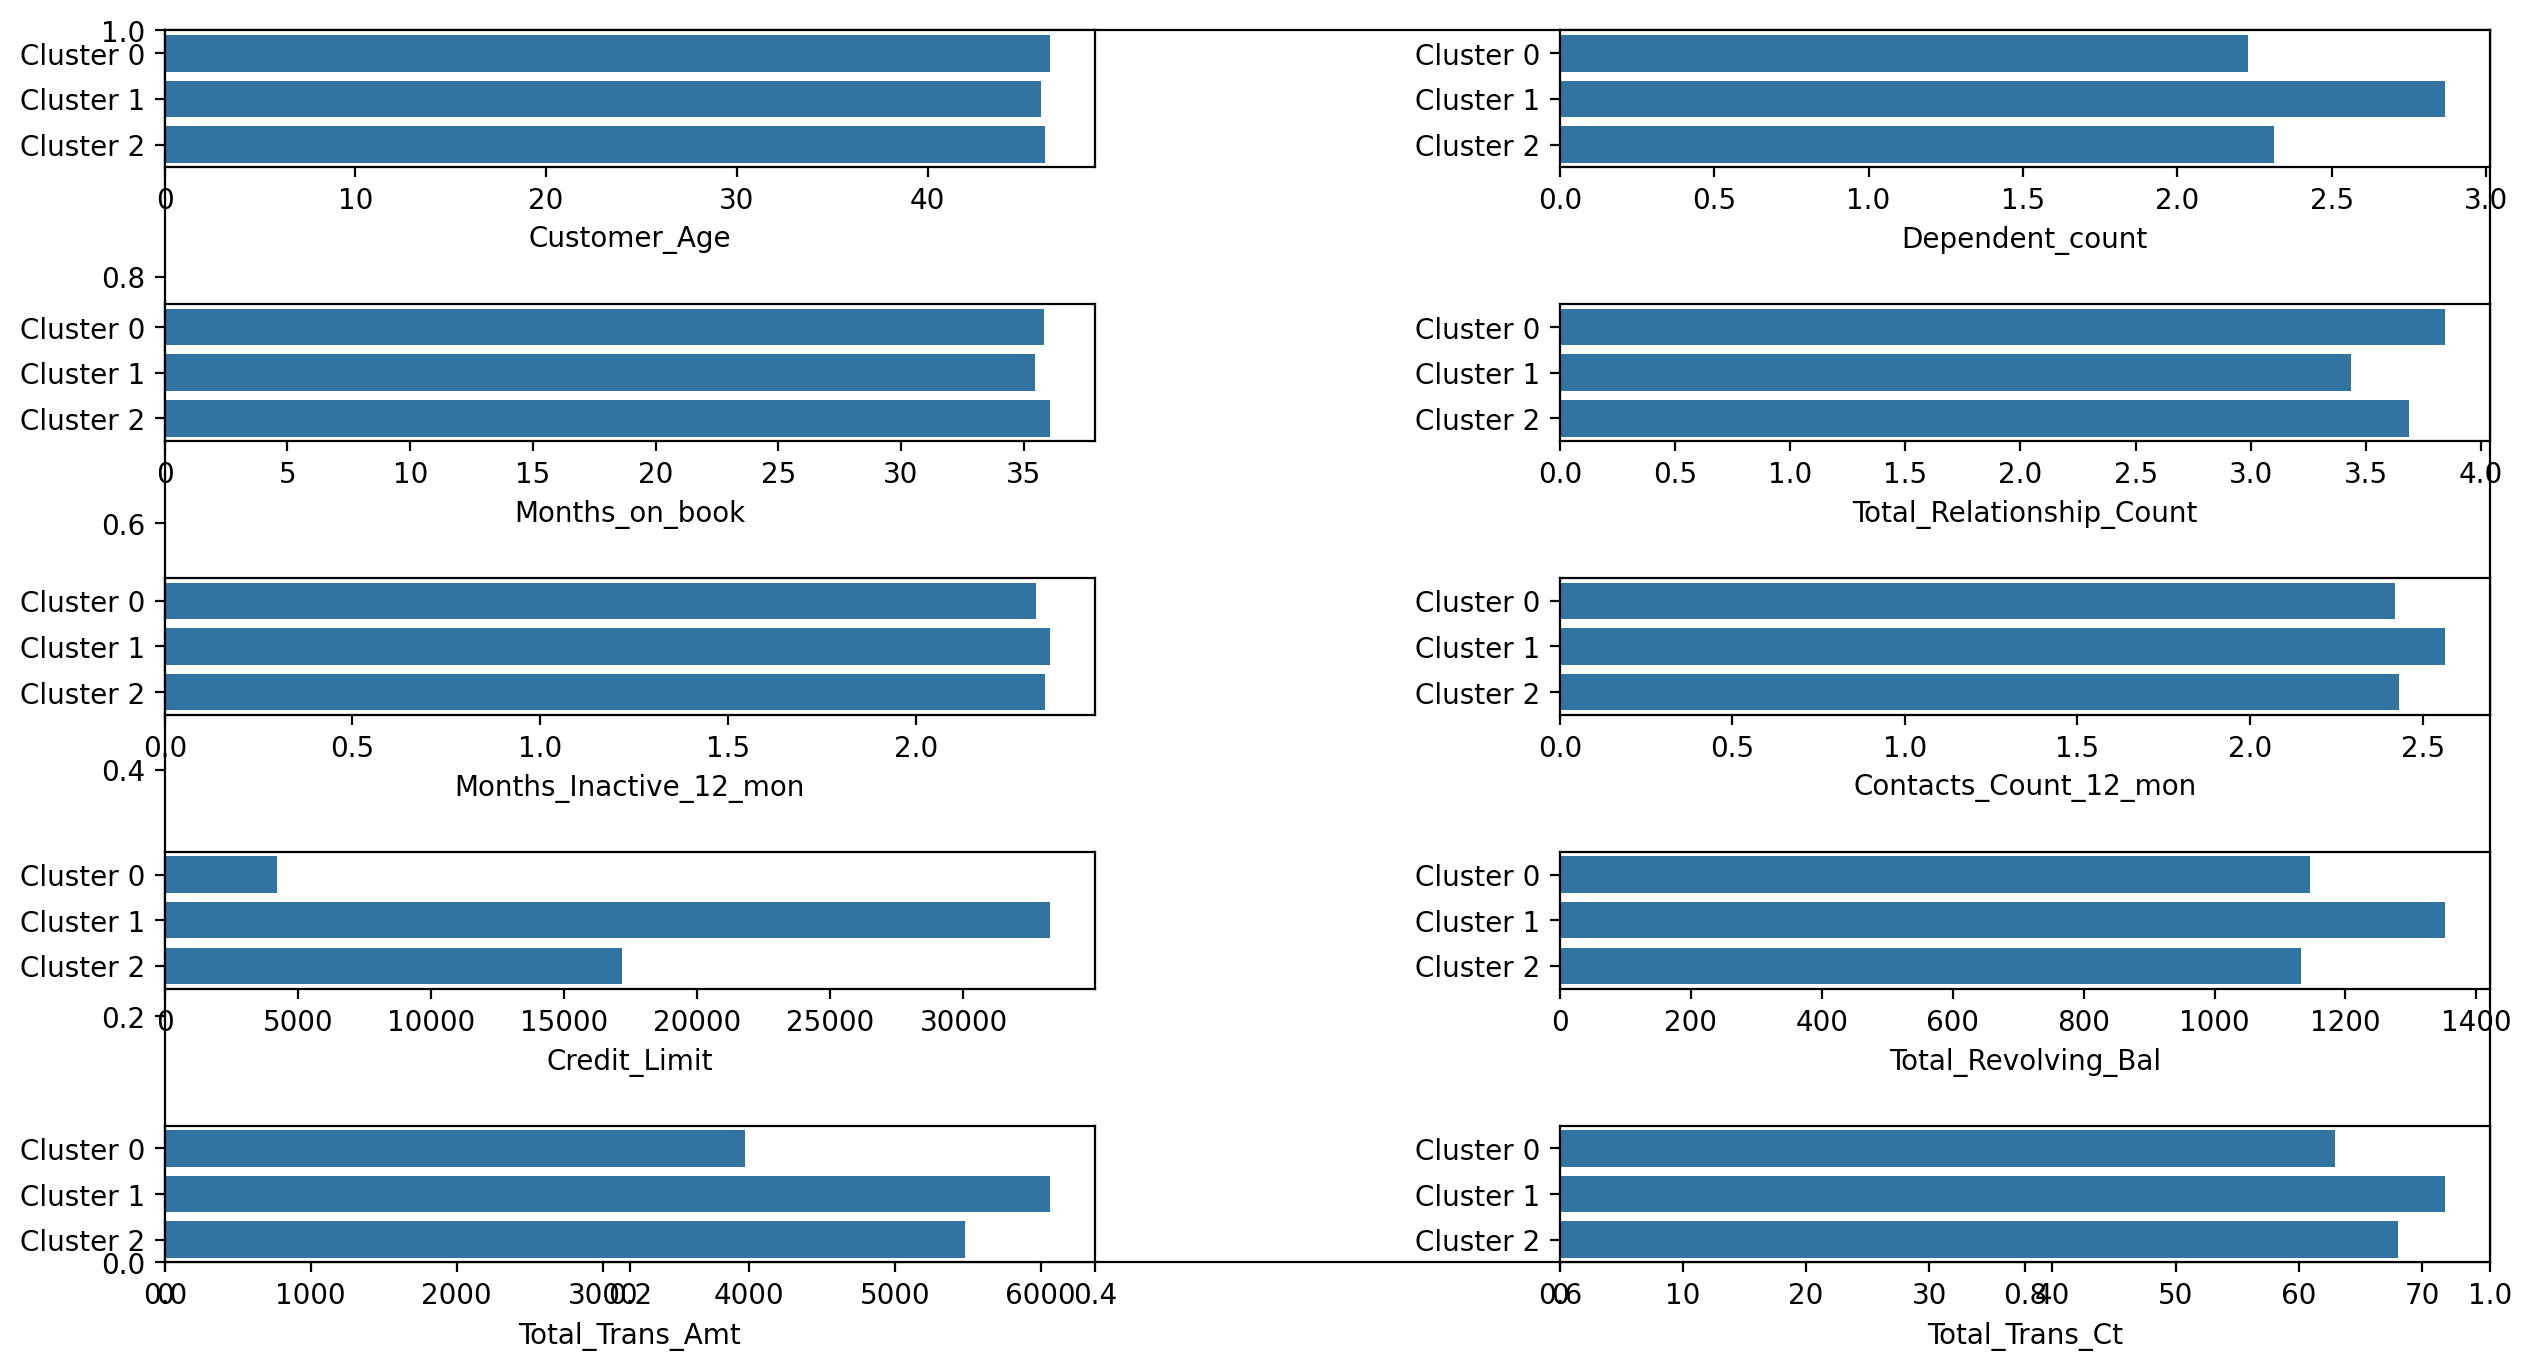

In [129]:
# Gráfico de tipo Barra-Detallado
print(centros)
ns.bar_plot_detail(centros, df_numerico.columns)
plt.show()

In [130]:
# Grafico de tipo Radar
grupos = fcluster(linkage(df_numerico, method = 'ward', metric='euclidean'), 3, criterion = 'maxclust')
grupos = grupos-1 # Se resta 1 para que los clústeres se enumeren de 0 a (K-1), como usualmente lo hace Python
# El siguiente print es para ver en qué cluster quedó cada individuo
grupos

array([0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0,
       2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2,
       0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 2, 2, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,

In [131]:
centros = np.array(pd.concat([ns.centroide(0, df_numerico, grupos), 
                              ns.centroide(1, df_numerico, grupos),
                              ns.centroide(2, df_numerico, grupos)]))
centros

array([[4.64446203e+01, 2.22943038e+00, 3.58386076e+01, 3.84493671e+00,
        2.32120253e+00, 2.42088608e+00, 4.22284731e+03, 1.14586392e+03,
        3.97528323e+03, 6.29208861e+01],
       [4.59622642e+01, 2.86792453e+00, 3.54528302e+01, 3.43396226e+00,
        2.35849057e+00, 2.56603774e+00, 3.32653019e+04, 1.35262264e+03,
        6.06701887e+03, 7.19056604e+01],
       [4.61840000e+01, 2.31200000e+00, 3.60880000e+01, 3.68800000e+00,
        2.34400000e+00, 2.43200000e+00, 1.71836480e+04, 1.13212000e+03,
        5.48491200e+03, 6.80560000e+01]])

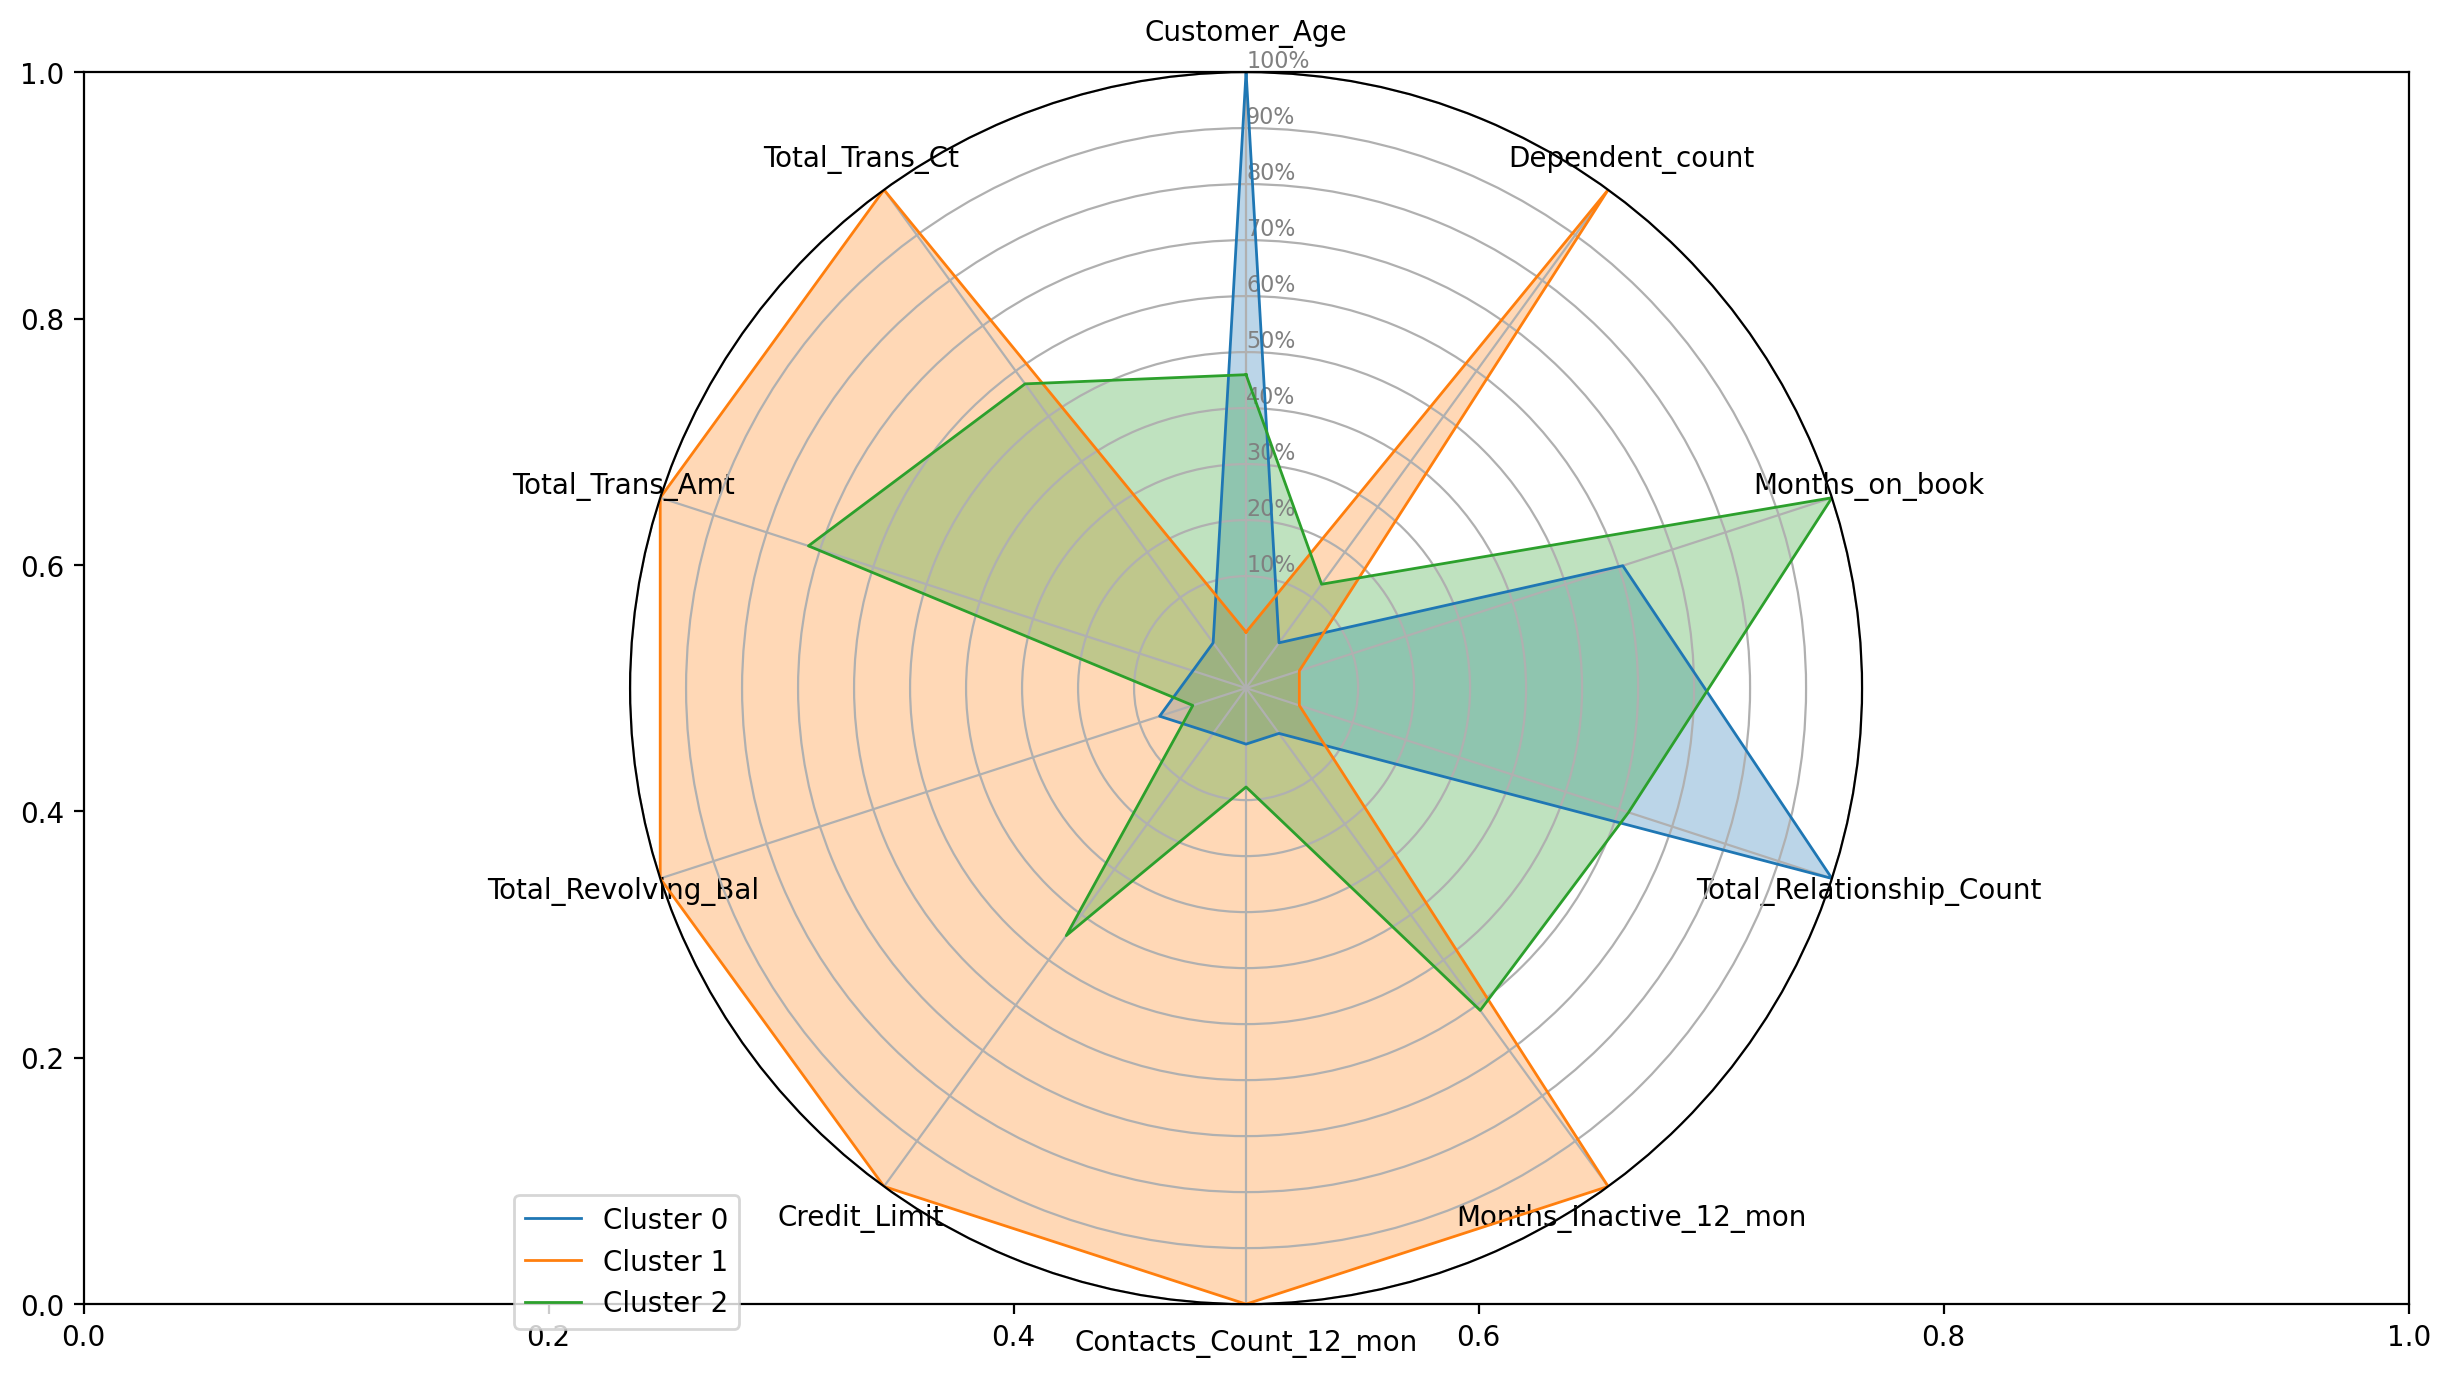

In [132]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

In [133]:
# Opción d
# se realiza el PCA
df_numerico['grupo']=grupos

In [134]:
df_scaled = pd.DataFrame(StandardScaler().fit_transform(df_numerico),columns=df_numerico.columns,
                                   index = df_numerico.index) #La clase StandardScaler tiene el método fit_transform que estandariza los datos y además lo pasamos a una estructura de dataframe                                  
# Instancia PCA, reduce las dimensiones a 2                              
pca = PCA(n_components = 2)  
#Obtiene los componentes principales
componentes = pca.fit_transform(df_scaled) # El método fit_transform de la instancia PCA genera los cálculos del ACP
df.shape

(810, 15)

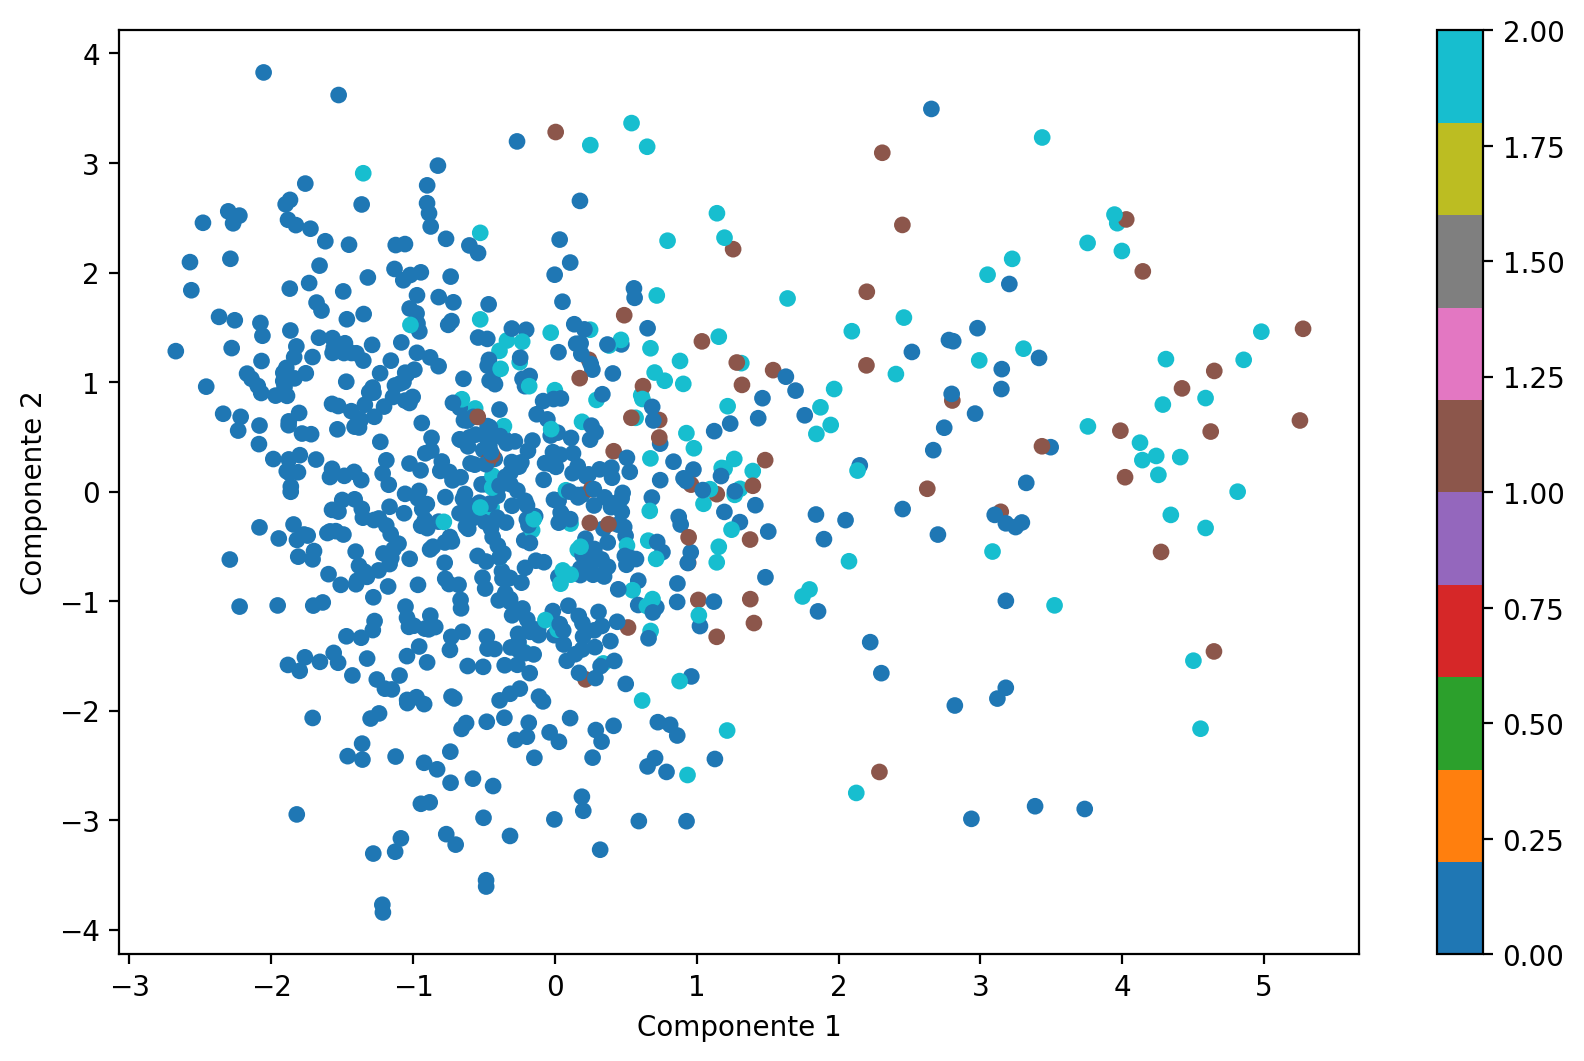

In [135]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize = (10,6), dpi = 200)
plt.scatter(componentes[:, 0], componentes[:, 1],
c=df_numerico.grupo, edgecolor='none', alpha=1,
cmap=plt.colormaps.get_cmap('tab10'))
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.colorbar()
plt.show()